# Exemplo modelo risco de crédito — **Revisão técnica comentada (Credit Risk Code Review)**

Este é o notebook original **revisado linha a linha** por um Cientista de Dados Sênior de Risco de Crédito. Ele serve para duas coisas:

1. **Material de estudo:** cada bloco de código tem, **antes** dele, um comentário explicando *o que* a linha faz, *por que* existe, *qual problema resolve*, *qual a consequência no pipeline* e *como se liga a Credit Risk*. Células Markdown explicam os conceitos maiores.
2. **Code review:** os problemas metodológicos foram identificados, explicados e, quando faz sentido, **corrigidos em células novas ao lado do código original**. O código original **não foi alterado silenciosamente**: todas as suas linhas continuam aqui, na mesma ordem, e produzem **exatamente os mesmos números** do notebook que você enviou.

### Como ler as marcações

| Marcação | Significado |
|---|---|
| **`[ORIGINAL — célula N]`** | Célula do notebook original (N = posição original), com comentários adicionados. O código é o mesmo. |
| **🔴 P#** | Problema metodológico ou de implementação: *Problema → Por que é um problema → Impacto → Correção*. |
| **🟡 Atenção** | Ponto que não é um erro, mas exige cuidado (limitação, hipótese, simplificação). |
| **🟢 Correto** | Decisão tecnicamente adequada — vale entender por quê, para repetir em outros projetos. |
| **✅ Correção** | Célula **nova**, que implementa e mede a correção proposta. |

### Mapa de alterações (tudo o que mudou em relação ao original)

| Alteração | Onde | Motivo |
|---|---|---|
| Comentários antes de cada bloco de código | Todas as células originais | Pedido de material didático |
| Comentários de fim de linha movidos para a linha de cima | Células originais 2, 6 e 12 | Leitura de cima para baixo (regra "comentário antes do código") |
| Linhas em branco entre chamadas de formatação de gráfico removidas | Células de EDA (originais 14–22) | Agrupar `plt.title`/`plt.show` etc. sob um único comentário; nenhuma linha de código mudou |
| **A EDA (células originais 14–22) foi movida** para antes da modelagem | Seção 4 | A EDA estava **depois** do modelo; análise exploratória deve orientar a modelagem, não vir depois dela (ver P6) |
| Células **✅ Correção** novas | Ao longo do notebook | Implementam e medem cada correção sem mexer no código original |
| Seção final **Credit Risk — Technical Review** | Fim | Auditoria pedida |

Nenhuma linha de código original foi apagada ou modificada; as células originais continuam usando o modelo original, para que você compare seus resultados com os resultados corrigidos.

### Sumário
0. Setup · 1. Problema de negócio e definições · 2. Dados · 3. Split e desenho da validação · 4. EDA · 5. Modelagem · 6. Avaliação (discriminação e calibração) · 7. Threshold · 8. Expected Loss e P&L · 9. Política de crédito · 10. Estabilidade e stress · 11. CLV · 12. Interpretabilidade · 13. Comparação final no OOT · 14. Ordem do pipeline · **Credit Risk — Technical Review**

## 0. Setup

As bibliotecas definem o "kit" do projeto: `numpy`/`pandas` para dados, `scikit-learn` para o pipeline (imputação, encoding, calibração, métricas), `lightgbm` para o modelo de boosting e `matplotlib` para diagnósticos.

> 🟢 **Correto:** fixar `RANDOM_STATE` torna o experimento reprodutível — requisito de governança de modelos (um validador independente precisa conseguir reproduzir os números).
>
> 🟡 **Atenção:** `train_test_split`, `calibration_curve` e `roc_curve` são importados mas **nunca usados** no original. Não é um erro, mas importações mortas confundem quem lê: `train_test_split` sugere um split aleatório que não existe, e `calibration_curve` sugere uma análise de calibração que **não foi feita** (ver P11). Nesta revisão, `calibration_curve` passa a ser usada.

In [2]:
# [ORIGINAL — célula 1]

# numpy faz as contas vetoriais do projeto: sorteios da base sintética, log-odds,
# probabilidades e cortes. Em crédito operamos sobre milhares de clientes ao mesmo
# tempo, e fazer isso em vetores (e não em loops) é o que torna o pipeline viável.
import numpy as np
# pandas guarda a base de crédito como tabela (1 linha = 1 cliente), permitindo
# separar safras, calcular bad rate por grupo e montar a carteira de P&L.
import pandas as pd
# matplotlib produz os gráficos de EDA e de política. Em risco, gráficos como a
# curva de lucro são evidência apresentada a comitê, não apenas decoração.
import matplotlib.pyplot as plt

# train_test_split: importado, mas nunca usado (o split é temporal, por safra).
# Mantido para preservar o original; em produção, remova importações mortas.
from sklearn.model_selection import train_test_split
# Pipeline encadeia pré-processamento + modelo num único objeto. Isso garante que
# a mesma transformação aprendida no treino seja aplicada na escoragem — a principal
# defesa contra "training-serving skew" e contra vazamento no pré-processamento.
from sklearn.pipeline import Pipeline
# ColumnTransformer aplica transformações diferentes para colunas numéricas e
# categóricas (imputação nas numéricas, one-hot nas categóricas).
from sklearn.compose import ColumnTransformer
# SimpleImputer preenche valores ausentes (aqui, renda não informada). Por estar
# dentro do Pipeline, a mediana é aprendida só com os dados de treino.
from sklearn.impute import SimpleImputer
# OneHotEncoder transforma categorias (região, canal) em colunas 0/1, formato que
# o modelo consegue usar sem impor uma ordem artificial entre as categorias.
from sklearn.preprocessing import OneHotEncoder
# CalibratedClassifierCV ajusta a escala das probabilidades para que a PD prevista
# corresponda à frequência observada de default. calibration_curve (importada e não
# usada no original) é justamente a ferramenta para verificar essa correspondência.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
# Métricas: AUC mede ordenação (discriminação); Brier mede a qualidade da
# probabilidade (calibração + discriminação). roc_curve é importada e não usada.
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

# LightGBM: gradient boosting de árvores, padrão de mercado para dados tabulares.
# Captura não linearidades e interações sem feature engineering manual.
from lightgbm import LGBMClassifier

# Formata floats com 3 casas e separador de milhar, para ler tabelas de carteira
# (valores em R$ e taxas) sem notação científica.
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
# Semente única para todo o experimento: reprodutibilidade é exigência de
# validação independente de modelos (model risk management).
RANDOM_STATE = 42
# Semente do gerador global do numpy. Na prática, o gerador de dados usa
# default_rng(seed) próprio, então esta linha é redundante — mas inofensiva.
np.random.seed(RANDOM_STATE)

In [3]:
# ✅ Correção / complemento — bibliotecas usadas nas células novas desta revisão.

# clone copia a CONFIGURAÇÃO de um estimador sem os parâmetros aprendidos. Usamos
# para treinar variações do modelo sem alterar os objetos do notebook original.
from sklearn.base import clone
# Regressão logística: o benchmark obrigatório em Credit Risk (interpretável,
# estável, naturalmente bem calibrada). O original não tinha nenhum baseline.
from sklearn.linear_model import LogisticRegression, LinearRegression
# StandardScaler padroniza as variáveis para a logística (coeficientes comparáveis
# e regularização aplicada de forma justa entre variáveis de escalas diferentes).
from sklearn.preprocessing import StandardScaler
# Métricas que faltavam: log loss (qualidade probabilística), PR-AUC (desempenho na
# classe rara) e matriz de confusão (para métricas dependentes de threshold).
from sklearn.metrics import log_loss, average_precision_score, confusion_matrix
# Importância por permutação: mede quanto a performance cai quando embaralhamos uma
# variável — uma medida de importância PREDITIVA, independente do tipo de modelo.
from sklearn.inspection import permutation_importance
# scipy.stats: testes estatísticos (qui-quadrado, binomial) para separar sinal de ruído.
from scipy import stats
# seaborn é usado pela EDA original (lá ele é importado dentro das células).
import seaborn as sns

## 1. O problema de negócio e as definições que faltam

**Objetivo do notebook (inferido do código):** estimar a **Probability of Default (PD)** de clientes de um banco, usar essa PD para calcular a **perda esperada (Expected Loss)** e o **lucro ajustado ao risco** de cada cliente, e daí derivar uma **política de crédito** (corte de PD e faixas A–E de decisão), além de monitoramento (PSI) e valor do cliente (CLV).

**Que tipo de modelo é este?** As variáveis são de **clientes que já têm relacionamento com o banco**: tempo de casa, número de produtos, **utilização do limite**, atrasos nos últimos 12 meses. Isso caracteriza um **behavior score** (score de comportamento), usado para gestão de limite, renovação e oferta de novos produtos — e não um *application score* de concessão para clientes novos.

### Classificação × score × probabilidade × PD

Estes quatro termos são usados como sinônimos, mas **não são**:

| Conceito | O que é | Exemplo | Serve para |
|---|---|---|---|
| **Classificação** | Rótulo 0/1 obtido comparando uma saída do modelo com um threshold | "vai dar default" | Decisão binária, **depende do threshold** |
| **Score** | Número que **ordena** clientes; a escala não tem significado próprio | 720 pontos | Ranking, cortes por percentil |
| **Probabilidade** | Número entre 0 e 1 produzido pelo modelo (`predict_proba`) | 0,18 | Só vira "probabilidade de verdade" se estiver **calibrada** |
| **PD** | Probabilidade **calibrada** de default num **horizonte definido** (ex.: 12 meses) e para uma **definição de default** (ex.: 90+ dias de atraso) | PD 12m = 18% | Precificação, provisão, capital, Expected Loss |

**O que significa `PD = 0,18`?** Que, entre muitos clientes com o mesmo perfil deste, esperamos que **cerca de 18 em cada 100 entrem em default** dentro do horizonte. Não significa que "este cliente está 18% inadimplente", nem que ele "vai dar default" — o evento é binário e a PD é uma **frequência esperada** para clientes parecidos. Essa leitura só é legítima se o modelo estiver **calibrado**: se o modelo diz 18% para um grupo e esse grupo dá default em 9%, o número 0,18 é só um score, não uma PD.

### 🔴 P1 — O notebook não define o evento de default, o horizonte nem a data de observação

- **Problema:** o target `default` surge de um sorteio, sem definição de **evento** (ex.: 90 dias de atraso), **janela de desempenho** (ex.: 12 meses após a data de observação) nem **data de observação** (o "instante da foto" em que as features são medidas).
- **Por que é um problema:** em Credit Risk, *toda* feature precisa estar disponível **na data de observação**, e o target é medido **depois** dela. Sem essa linha do tempo, não dá para auditar leakage (uma variável medida durante a janela de desempenho vaza o futuro), nem interpretar a PD (PD de quê? em quanto tempo?).
- **Impacto:** um validador independente não conseguiria aprovar o modelo; a PD não poderia ser usada em provisão (IFRS 9 / Resolução CMN 4.966, que exigem horizonte explícito) nem em precificação.
- **Correção:** documentar no topo do notebook, por exemplo: *"Default = 90+ dias de atraso em qualquer contrato nos 12 meses após a data de observação (último dia do mês da safra). Features medidas até a data de observação."* Para dados sintéticos, basta declarar a convenção; para dados reais, construir o target a partir do histórico de atraso respeitando essa janela.

## 2. Dados — a função geradora `gerar_base`

O notebook **simula** a base. Isso tem uma vantagem didática enorme: conhecemos o **mecanismo verdadeiro** (`logit` abaixo) e a **PD verdadeira** de cada cliente (`pd_real`). Assim podemos medir o quanto o modelo se aproxima da verdade — algo impossível com dados reais.

**Significado financeiro das variáveis geradas:**

| Variável | Significado | Relação esperada com o risco |
|---|---|---|
| `idade` | Idade do cliente | Em geral, mais jovem ⇒ mais risco (menos estabilidade) |
| `tempo_casa_meses` | Tempo de relacionamento com o banco | Mais tempo ⇒ menos risco e mais informação sobre o cliente |
| `renda_mensal` | Renda declarada | Mais renda ⇒ mais capacidade de pagamento (efeito saturado) |
| `utilizacao_limite` | Saldo usado ÷ limite (**credit utilization**) | Uso alto = cliente dependente do crédito, pouco "fôlego" ⇒ mais risco |
| `atrasos_12m` | Nº de atrasos em 12 meses (**delinquency**) | Comportamento passado é o melhor preditor de comportamento futuro |
| `atraso_max_dias` | Pior atraso em 12 meses | Gravidade da inadimplência passada |
| `n_produtos` | Nº de produtos com o banco | Vínculo/principalidade ⇒ menos risco |
| `consultas_bureau_6m` | Consultas ao bureau em 6 meses | Busca intensa por crédito = sinal de aperto financeiro |
| `dti` | **Debt-to-income**: dívida (EAD) ÷ renda anual | Comprometimento da renda ⇒ capacidade de pagamento |
| `limite_aprovado` | Limite concedido pelo banco | Decisão do próprio banco (atenção: risco de circularidade) |
| `ead` | **Exposure at Default**: quanto o banco perde se o cliente parar de pagar (aqui = saldo utilizado) | Não é feature; entra no cálculo de perda |
| `regiao`, `canal_aquisicao` | Região e canal de entrada | Proxies de perfil; exigem cuidado com causalidade e equidade |
| `pd_real` | PD verdadeira (só existe em dados sintéticos) | **Nunca** usar como feature |

Features financeiras clássicas que **não existem** nesta base e costumam ser muito preditivas: **payment-to-income** (valor da parcela ÷ renda — mede o aperto mensal, e não o estoque de dívida como o DTI), **income stability** (variação da renda ao longo dos meses) e **delinquency rate** (atrasos ÷ nº de parcelas devidas, que normaliza o nº de atrasos pelo nº de oportunidades de atrasar).

In [4]:
# [ORIGINAL — célula 2]

# Função que simula o "mundo real": gera n clientes com características e um
# default sorteado a partir de um mecanismo causal conhecido. Parametrizar n, seed e
# safra inicial permite recriar bases (a célula de stress test usa isso depois).
def gerar_base(n=20000, seed=42, safra_inicial="2024-01"):
    # Gerador aleatório próprio (e não o global): garante que a mesma seed produz
    # exatamente a mesma base, requisito de reprodutibilidade.
    rng = np.random.default_rng(seed)

    # Idade uniforme entre 20 e 70 anos. Simplificação: carteiras reais concentram
    # clientes em faixas etárias intermediárias.
    idade        = rng.integers(20, 71, n)
    # Tempo de relacionamento entre 1 e 120 meses (uniforme).
    tempo_casa   = rng.integers(1, 121, n)
    # Renda log-normal (assimétrica à direita, como renda real), com piso e teto.
    # O clip cria massas artificiais nos extremos (264 clientes exatamente em R$ 1.200)
    # — uma forma de "outlier tratado" que aparece como pico na distribuição.
    renda        = np.exp(rng.normal(8.3, 0.55, n)).clip(1200, 60000)
    # Utilização do limite ~ Beta(2,3): valores entre 0 e 1, média 0,4.
    utilizacao   = rng.beta(2, 3, n)
    # Nº de atrasos em 12 meses ~ Poisson(0,8): maioria sem atraso, cauda com vários.
    atrasos_12m  = rng.poisson(0.8, n).clip(0, 12)
    # Pior atraso = nº de atrasos × dias sorteados. Por construção é quase uma função
    # de atrasos_12m (correlação de Spearman 0,93): duas variáveis contando a mesma
    # história — fonte de multicolinearidade (ver P7).
    atraso_max   = (atrasos_12m * rng.integers(5, 35, n)).clip(0, 180)
    # Nº de produtos com o banco (1 a 6).
    n_produtos   = rng.integers(1, 7, n)
    # Consultas ao bureau em 6 meses ~ Poisson(1,2).
    consultas_6m = rng.poisson(1.2, n).clip(0, 15)
    # Região com proporções fixas. No mecanismo causal abaixo a região NÃO tem efeito
    # nenhum: qualquer diferença de bad rate entre regiões na EDA é ruído amostral.
    regiao = rng.choice(["SE","S","NE","CO","N"], n, p=[.45,.18,.22,.09,.06])
    # Canal de aquisição. PARCEIRO terá efeito positivo no risco (ver logit).
    canal  = rng.choice(["APP","AGENCIA","PARCEIRO"], n, p=[.55,.25,.20])

    # Limite = renda × fator entre 1 e 4. Em um banco real o limite é DECIDIDO pelo
    # banco com base no risco percebido; usar essa decisão como feature cria
    # circularidade (o modelo aprende a política antiga). Aqui não há leakage porque o
    # limite depende só da renda, mas o risco conceitual existe (ver P3).
    limite = (renda * rng.uniform(1.0, 4.0, n)).clip(1000, 120000)
    # EAD = limite × utilização, com piso de R$ 300 (exposição no default).
    # Simplificação: EAD = saldo ATUAL. Em produtos rotativos o cliente costuma sacar
    # parte do limite livre antes de parar de pagar; o correto seria
    # EAD = saldo + CCF × (limite − saldo) (ver P4).
    ead    = (limite * utilizacao).clip(300, None)
    # DTI = EAD ÷ renda anual (endividamento), limitado a 3.
    # Atenção: o DTI é calculado com a renda VERDADEIRA, antes de a renda ser apagada
    # para 4% dos clientes (mais abaixo). Na vida real, sem renda informada não há
    # como calcular DTI — aqui o DTI "carrega" a renda que deveria estar ausente (P2).
    dti    = (ead / (renda * 12)).clip(0, 3)

    # ---- mecanismo causal (o "mundo real" que o modelo deve descobrir) ----
    # Log-odds verdadeiro do default: combinação LINEAR das variáveis (mais dois
    # degraus: renda > 9000 e canal PARCEIRO). Como o mundo é quase linear no logit,
    # uma regressão logística deveria se sair muito bem — um boosting não tem
    # vantagem estrutural aqui (e veremos que ele perde por overfitting).
    logit = (
        # Intercepto: define o nível médio de default (~7,7%).
        -3.55
        # uso alto do limite = sinal forte
        + 3.60  * utilizacao
        # comportamento passado manda
        + 0.42  * atrasos_12m
        + 0.016 * atraso_max
        # capacidade de pagamento
        + 1.90  * dti
        # busca por crédito = estresse
        + 0.30  * consultas_6m
        - 0.030 * (idade - 20)
        # relacionamento reduz risco
        - 0.016 * tempo_casa
        - 0.14  * n_produtos
        - 0.70  * (renda > 9000)
        + 0.45  * (canal == "PARCEIRO")
    )
    # Função logística: converte log-odds em probabilidade. É exatamente a forma
    # funcional da regressão logística — p = 1 / (1 + e^(−logit)).
    p_real  = 1 / (1 + np.exp(-logit))
    # O default observado é um sorteio de Bernoulli com probabilidade p_real. Mesmo um
    # modelo perfeito não acerta cada cliente: o acaso limita o AUC máximo possível
    # (o "oráculo", que calculamos na seção 6).
    default = rng.binomial(1, p_real)

    # safras mensais -> permite split out-of-time
    # Cada cliente recebe uma safra SORTEADA, independente de todo o resto. Logo não
    # existe nenhuma dinâmica temporal (sem ciclo, sem drift): o "out-of-time" deste
    # notebook é, na prática, um holdout aleatório (ver P5).
    safras = pd.period_range(safra_inicial, periods=12, freq="M")
    safra  = rng.choice(safras.astype(str), n)

    # Monta a tabela final: identificador, safra, features, EAD, PD real e target.
    df = pd.DataFrame({
        "customer_id": np.arange(1, n+1),
        "safra": safra,
        "idade": idade,
        "tempo_casa_meses": tempo_casa,
        "renda_mensal": renda.round(2),
        "utilizacao_limite": utilizacao.round(4),
        "atrasos_12m": atrasos_12m,
        "atraso_max_dias": atraso_max,
        "n_produtos": n_produtos,
        "consultas_bureau_6m": consultas_6m,
        "dti": dti.round(4),
        "limite_aprovado": limite.round(2),
        "ead": ead.round(2),
        "regiao": regiao,
        "canal_aquisicao": canal,
        # só para diagnóstico, NUNCA como feature
        "pd_real": p_real.round(5),
        "default": default,
    })

    # dados faltantes realistas (renda não informada)
    # 4% das rendas são apagadas AO ACASO (missing completamente aleatório — MCAR).
    # Na vida real, a renda costuma faltar de forma informativa (MNAR): autônomos,
    # informais e clientes que preferem não declarar têm outro perfil de risco (P2).
    faltantes = rng.choice(n, int(0.04*n), replace=False)
    df.loc[faltantes, "renda_mensal"] = np.nan
    return df

# Gera a base de desenvolvimento com os parâmetros padrão (20 mil clientes).
df = gerar_base()
# Volume e bad rate geral: o primeiro número que um comitê pergunta. ~7,7% de
# default caracteriza uma classe minoritária (desbalanceamento moderado).
print(f"Registros: {len(df):,}")
print(f"Bad rate geral: {df['default'].mean():.2%}")
# Primeiras linhas: checagem visual de tipos, escalas e valores plausíveis.
df.head()

Registros: 20,000
Bad rate geral: 7.71%


,customer_id,safra,idade,tempo_casa_meses,renda_mensal,utilizacao_limite,atrasos_12m,atraso_max_dias,n_produtos,consultas_bureau_6m,dti,limite_aprovado,ead,regiao,canal_aquisicao,pd_real,default
0,1,2024-01,24,5,"1,474.130",0.086,1,9,3,2,0.019,"3,885.800",333.120,CO,AGENCIA,0.065,0
1,2,2024-11,59,87,"3,238.680",0.198,2,28,6,0,0.027,"5,325.880","1,054.430",SE,AGENCIA,0.007,0
2,3,2024-05,53,26,"1,538.220",0.481,1,22,4,1,0.048,"1,850.240",890.610,SE,APP,0.068,0
3,4,2024-04,42,86,"12,367.730",0.789,0,0,6,1,0.225,"42,350.090","33,428.140",SE,APP,0.028,0
4,5,2024-12,42,68,"4,522.730",0.157,1,22,6,3,0.032,"10,985.310","1,726.110",S,APP,0.021,0


### Revisão dos dados

> 🟢 **Correto:** `pd_real` é mantida na base **apenas para diagnóstico** e **fica fora da lista de features**. `customer_id` também fica de fora (um ID não tem significado preditivo, e usá-lo seria decorar clientes). Cada cliente aparece **uma única vez**, então não há risco de o mesmo cliente estar no treino e no teste.

### 🔴 P2 — Missing aleatório e DTI calculado com a renda "apagada"

- **Problema:** (a) a renda falta **completamente ao acaso (MCAR)**, o que é irrealista; (b) o `dti` é calculado com a renda **verdadeira** antes de ela ser apagada. Como `dti = ead / (12 × renda)` e `ead = limite × utilização`, a renda "ausente" pode ser recuperada exatamente: `renda = limite × utilização / (12 × dti)`.
- **Por que é um problema:** (a) na vida real, **o missing costuma ser informativo**: quem não declara renda tende a ser autônomo, informal ou a ter algo a esconder. O próprio fato de faltar é um sinal de risco, e imputar a mediana **apaga esse sinal**. (b) O DTI de um cliente sem renda informada **não existiria**: aqui ele carrega uma informação que o banco não teria — é uma inconsistência do gerador que "vaza" a renda verdadeira.
- **Impacto:** o notebook ensina que imputar a mediana é inofensivo — o que só é verdade porque o missing foi simulado como MCAR (no treino, a bad rate de quem não tem renda é 6,9% contra 7,7% dos demais — diferença dentro do ruído amostral, com ~580 clientes sem renda; seção 4). Com missing informativo, a imputação pela mediana **empurra clientes arriscados para o perfil médio** e o modelo subestima o risco deles.
- **Correção:** (i) sempre criar uma **flag de missing** (`SimpleImputer(add_indicator=True)`), para o modelo aprender se "não informar" tem significado; (ii) quando a renda falta, o `dti` também deve faltar (e ter a sua própria flag); (iii) analisar a bad rate de quem tem missing **antes** de escolher a imputação (feito na seção 4).

### 🔴 P3 — `limite_aprovado` é uma decisão do banco usada como feature

- **Problema:** o limite é **decidido pelo banco** com base no risco que ele enxergava. Usá-lo como feature cria **circularidade**: o modelo aprende a política de crédito antiga, e não o risco do cliente.
- **Por que é um problema:** se a política mudar (ex.: o banco passar a dar limites maiores), a variável muda de significado e o modelo erra. Além disso, na decisão de **aumentar** limite (faixa A do notebook), a feature depende da própria decisão que o modelo deveria apoiar.
- **Impacto:** instabilidade do modelo quando a política muda; métricas otimistas se o limite antigo já embutia um julgamento de risco. Nesta base sintética o limite depende só da renda, então o impacto numérico é nulo — mas o **desenho** está errado para uso real.
- **Correção:** preferir variáveis de **comportamento do cliente** (saldo, utilização, pagamentos) às variáveis de **decisão do banco** (limite, taxa, prazo); se o limite for mantido, documentar a justificativa e monitorar mudanças de política.

### 🔴 P4 — EAD = saldo atual (sem fator de conversão de crédito)

- **Problema:** `ead = limite × utilização`, ou seja, o saldo atual.
- **Por que é um problema:** em produtos rotativos (cartão, cheque especial), o cliente que caminha para o default costuma **sacar o limite livre** antes de parar de pagar. A EAD correta é `saldo + CCF × (limite − saldo)`, com o **CCF** (*Credit Conversion Factor*) estimado a partir de defaults históricos.
- **Impacto:** Expected Loss **subestimada**, principalmente para clientes de baixa utilização (que têm mais limite livre para sacar) — exatamente os clientes que a política coloca na faixa "aprovar com limite **ampliado**", o que aumentaria ainda mais a exposição.
- **Correção:** estimar o CCF por faixa de utilização e produto; na decisão de mudança de limite, recalcular a EAD **com o novo limite**.

## 3. Features, target e split — o desenho da validação

Nesta etapa separamos os dados para medir a **capacidade de generalização** do modelo. Em Credit Risk, essa separação precisa **imitar o uso real**: o modelo é treinado com safras passadas e usado em safras futuras. Por isso o padrão de mercado é o split **out-of-time (OOT)**: treinar em safras antigas e testar em safras mais recentes, que o modelo nunca viu.

> 🟢 **Correto:** o notebook faz split **por safra** (treino = jan–set/2024, OOT = out–dez/2024) em vez de um `train_test_split` aleatório. É a escolha certa em crédito: um split aleatório mistura meses e esconde problemas de estabilidade temporal.
>
> 🟢 **Correto:** a lista de features exclui `customer_id`, `safra`, `ead`, `pd_real` e o próprio target.

**Disponibilidade das features na data de decisão (checagem de target leakage):**

| Feature | Disponível na data de observação? | Comentário |
|---|---|---|
| idade, tempo de casa, renda, nº de produtos, região, canal | Sim | Cadastro/relacionamento |
| utilização, atrasos 12m, atraso máximo, consultas 6m | Sim, **se** medidas até a data de observação | Janelas "12m"/"6m" devem terminar **antes** do início da janela de desempenho |
| dti | Sim, mas inconsistente | Calculado com a renda verdadeira mesmo quando ela falta (P2) |
| limite_aprovado | Sim | Decisão do banco ⇒ circularidade (P3) |
| ead | Não é feature | Usado só no cálculo de perda — correto |
| pd_real, default | **Não** | Excluídos — correto |

Não há **target leakage** óbvio (nenhuma variável medida depois do evento), mas a ausência de uma data de observação documentada (P1) impede de **provar** isso.

In [5]:
# [ORIGINAL — célula 3]

# Features numéricas: comportamento, capacidade de pagamento e relacionamento.
# ead e pd_real ficam de fora de propósito: ead é insumo da perda (não do risco) e
# pd_real é a resposta verdadeira (usá-la seria o leakage mais grosseiro possível).
FEATS_NUM = ["idade","tempo_casa_meses","renda_mensal","utilizacao_limite","atrasos_12m",
             "atraso_max_dias","n_produtos","consultas_bureau_6m","dti","limite_aprovado"]
# Features categóricas: serão transformadas em colunas 0/1 pelo OneHotEncoder.
FEATS_CAT = ["regiao","canal_aquisicao"]
# Lista final de entrada do modelo. Ter uma lista explícita (e não "todas as colunas
# menos o target") é uma proteção: uma coluna nova na base não entra no modelo sem
# que alguém decida isso conscientemente.
FEATURES  = FEATS_NUM + FEATS_CAT
# Variável resposta: 1 = default, 0 = adimplente.
TARGET    = "default"

# Lista ordenada das safras (meses). A ordenação é o que dá sentido ao "out-of-time".
safras = sorted(df["safra"].unique())
# A 10ª safra (out/2024) é o início do período de teste: 9 meses para treinar e 3 para
# testar, uma proporção comum (~75/25) que preserva safras recentes para o teste.
corte_oot = safras[9]

# Treino = safras anteriores ao corte; OOT = safras a partir do corte. O OOT simula
# "o modelo em produção nos meses seguintes ao desenvolvimento".
treino = df[df["safra"] <  corte_oot]
oot    = df[df["safra"] >= corte_oot]

# Separa matriz de features (X) e target (y) em cada período.
X_tr, y_tr = treino[FEATURES], treino[TARGET]
X_oot, y_oot = oot[FEATURES], oot[TARGET]

# Volumes e bad rate por período: bad rates muito diferentes entre treino e OOT
# indicariam mudança de regime (ciclo econômico), e a PD precisaria de ajuste.
print(f"Treino: {len(treino):,} | safras {safras[0]} a {safras[8]}")
print(f"OOT   : {len(oot):,} | safras {corte_oot} a {safras[-1]}")
print(f"Bad rate treino {y_tr.mean():.2%} | OOT {y_oot.mean():.2%}")

Treino: 14,958 | safras 2024-01 a 2024-09
OOT   : 5,042 | safras 2024-10 a 2024-12
Bad rate treino 7.67% | OOT 7.85%


### 🔴 P5 — O "out-of-time" é, na prática, um holdout aleatório, e não existe conjunto de validação

- **Problema:** (a) as safras são **sorteadas** de forma independente de tudo no gerador, então treino e OOT vêm da mesma distribuição — não há drift nem ciclo para o OOT detectar; (b) o notebook tem **só dois conjuntos**: treino e OOT. Todas as decisões posteriores (corte ótimo de PD, faixas, leitura do PSI) são tomadas **olhando o OOT**.
- **Por que é um problema:** (a) o OOT deveria responder "o modelo continua bom quando o tempo passa?"; aqui ele não tem como responder isso. (b) Quando uma escolha é feita no conjunto de teste, o teste deixa de ser uma medida independente: o resultado reportado fica **otimista** (*winner's curse*: a escolha que parece melhor no teste é, em parte, a mais sortuda nele).
- **Impacto:** o "Ganho da política" (R$ 306 mil) e o "corte ótimo" (0,185) foram escolhidos e medidos no mesmo conjunto — o número reportado não é uma estimativa honesta do ganho futuro.
- **Correção:** criar um **conjunto de validação temporal** dentro do período de treino — treinar em jan–jun (`fit_dev`), validar em jul–set (`val_dev`) — e usar a validação para **todas as escolhas** (modelo, hiperparâmetros, threshold). O OOT é usado **uma única vez**, no final, para medir o resultado das escolhas já feitas (seção 13). Com dados reais, verificar também a **estabilidade da bad rate por safra** (célula abaixo).

Qui-quadrado de homogeneidade da bad rate entre safras: p-valor = 0.626
fit_dev: 9,962 (2024-01 a 2024-06) | val_dev: 4,996 (2024-07 a 2024-09)


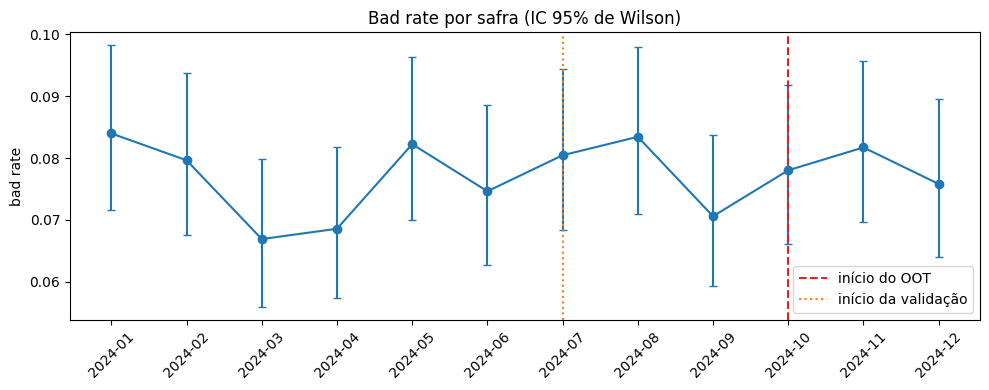

In [6]:
# ✅ Correção P5 — (1) bad rate por safra com intervalo de confiança; (2) validação temporal.

# Intervalo de Wilson para uma proporção: mais confiável que p ± 1,96·√(p(1−p)/n) quando
# p é pequena (bad rates de 5–10%) ou n é pequeno. Serve para separar variação real de
# ruído amostral em qualquer tabela de bad rate.
def wilson_ic(k, n, z=1.96):
    p = k / n
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    meia = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centro - meia, centro + meia

# Bad rate por safra: com dados reais é o primeiro gráfico de estabilidade temporal.
# Aqui esperamos oscilação só por ruído, porque as safras foram sorteadas.
por_safra = df.groupby("safra")["default"].agg(n="size", maus="sum")
por_safra["bad_rate"] = por_safra["maus"] / por_safra["n"]
por_safra["ic_inf"], por_safra["ic_sup"] = wilson_ic(por_safra["maus"], por_safra["n"])
# Teste qui-quadrado de homogeneidade: p-valor alto = as safras são compatíveis com a
# mesma taxa de default (nenhuma evidência de ciclo ou drift).
p_safra = stats.chi2_contingency(pd.crosstab(df["safra"], df["default"]))[1]
print(f"Qui-quadrado de homogeneidade da bad rate entre safras: p-valor = {p_safra:.3f}")

# Validação temporal DENTRO do período de treino: jan–jun para ajustar, jul–set para
# escolher modelo, hiperparâmetros e threshold. O OOT fica intocado até a seção 13.
fit_dev = treino[treino["safra"] <  safras[6]]
val_dev = treino[treino["safra"] >= safras[6]]
X_fit, y_fit = fit_dev[FEATURES], fit_dev[TARGET]
X_val, y_val = val_dev[FEATURES], val_dev[TARGET]
print(f"fit_dev: {len(fit_dev):,} ({safras[0]} a {safras[5]}) | val_dev: {len(val_dev):,} ({safras[6]} a {safras[8]})")

# Gráfico de bad rate por safra com IC: se a linha do OOT saísse da faixa do treino,
# seria sinal de mudança de regime.
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(por_safra.index, por_safra["bad_rate"],
            yerr=[por_safra["bad_rate"] - por_safra["ic_inf"], por_safra["ic_sup"] - por_safra["bad_rate"]],
            fmt="o-", capsize=3)
ax.axvline(corte_oot, color="tab:red", ls="--", label="início do OOT")
ax.axvline(safras[6], color="tab:orange", ls=":", label="início da validação")
ax.set_title("Bad rate por safra (IC 95% de Wilson)"); ax.set_ylabel("bad rate"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 4. Análise exploratória (EDA)

> **Mudança de ordem (documentada):** no notebook original, estas células (originais 14–22) vinham **depois** do modelo, da política e do monitoramento. Foram movidas para cá sem alteração do código.

### 🔴 P6 — EDA depois do modelo e sobre a base inteira (incluindo o OOT)

- **Problema:** a EDA foi feita depois da modelagem e usa `df`, que contém as safras do OOT.
- **Por que é um problema:** a EDA existe para **orientar** decisões de modelagem (transformações, tratamento de outliers, seleção de variáveis). Feita depois, não orientou nada. E olhar o conjunto de teste durante a exploração é uma forma sutil de **contaminação**: decisões inspiradas no teste tornam a avaliação final otimista.
- **Impacto:** aqui, pequeno (a EDA não mudou o modelo); num projeto real, é assim que o teste "vaza" para as escolhas do analista.
- **Correção:** fazer a EDA **antes** da modelagem e **apenas no treino** (as células ✅ abaixo usam `treino`). As células originais foram mantidas sobre `df` para preservar o código.

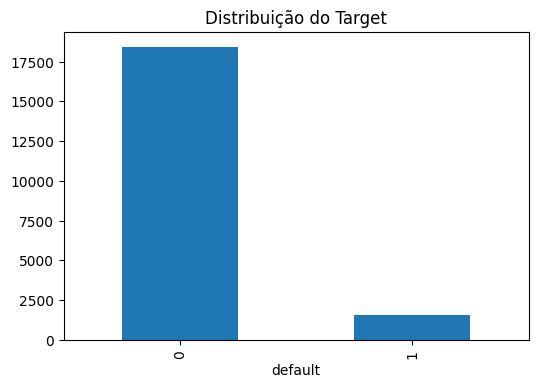

In [7]:
# [ORIGINAL — célula 21]

# Distribuição do target: a primeira pergunta de qualquer modelo de PD é "quantos
# defaults eu tenho?". Isso define o desbalanceamento e o quanto as métricas serão
# estáveis (o nº de EVENTOS, e não o nº de linhas, limita o que o modelo aprende).
counts = (
    df["default"]
    .value_counts()
)

# Gráfico de barras das duas classes: evidencia visualmente a classe minoritária.
counts.plot(
    kind="bar",
    figsize=(6,4)
)

# Título e exibição do gráfico.
plt.title(
    "Distribuição do Target"
)
plt.show()

### Desbalanceamento de classes em crédito

- **Por que o default é minoritário:** bancos só emprestam para quem acreditam que vai pagar. A carteira observada é, por construção, majoritariamente adimplente (aqui ~7,7% de default; em carteiras *prime*, 1–3%).
- **Por que accuracy engana:** um "modelo" que diz "ninguém dá default" acerta ~92% dos casos e não serve para nada. Accuracy mede a proporção de acertos, dominada pela classe majoritária.
- **Impacto em precision e recall:** com poucos maus, mesmo um bom modelo tem **precision baixa** (entre os reprovados, muitos seriam bons pagadores), e aumentar o **recall** (pegar mais maus) custa reprovar muitos bons. O equilíbrio entre os dois é uma decisão **econômica** (seção 7).
- **`class_weight` e resampling (SMOTE, undersampling):** mudam a proporção de classes que o modelo "vê" e, portanto, **distorcem a PD** (o modelo passa a achar que o default é muito mais comum). Podem ajudar na ordenação em casos extremos (ex.: 0,1% de eventos), mas exigem **recalibração** depois. Para PD, o padrão é treinar na distribuição real e escolher o threshold pela economia.

> 🟢 **Correto:** o notebook **não** aplica `class_weight` nem resampling. A célula abaixo mostra o que aconteceria.

In [8]:
# ✅ Demonstração — o efeito de class_weight="balanced" sobre a PD (validação temporal).

# Pipeline da logística (usado como baseline ao longo da revisão): imputação com flag de
# missing (P2) + padronização nas numéricas; one-hot nas categóricas.
def pipeline_logistica(class_weight=None):
    pre_lr = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]), FEATS_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATS_CAT),
    ])
    return Pipeline([("pre", pre_lr), ("clf", LogisticRegression(max_iter=2000, class_weight=class_weight))])

# Treinamos com e sem balanceamento em jan–jun e medimos em jul–set: o AUC (ordenação)
# quase não muda, mas a PD média se afasta completamente da taxa real de default.
for cw in [None, "balanced"]:
    p_cw = pipeline_logistica(cw).fit(X_fit, y_fit).predict_proba(X_val)[:, 1]
    print(f"class_weight={str(cw):9s} | AUC {roc_auc_score(y_val, p_cw):.4f} | "
          f"PD média prevista {p_cw.mean():.2%} | taxa real {y_val.mean():.2%}")

class_weight=None      | AUC 0.8242 | PD média prevista 7.68% | taxa real 7.81%
class_weight=balanced  | AUC 0.8242 | PD média prevista 37.30% | taxa real 7.81%


**Leitura.** O AUC é o mesmo nos dois casos (a ordenação não muda), mas com `class_weight="balanced"` a PD média vai para ~37% numa carteira que dá default em ~8%. Essa "PD" não serve para Expected Loss, preço ou provisão sem recalibração — e a recalibração desfaria exatamente o que o balanceamento fez.

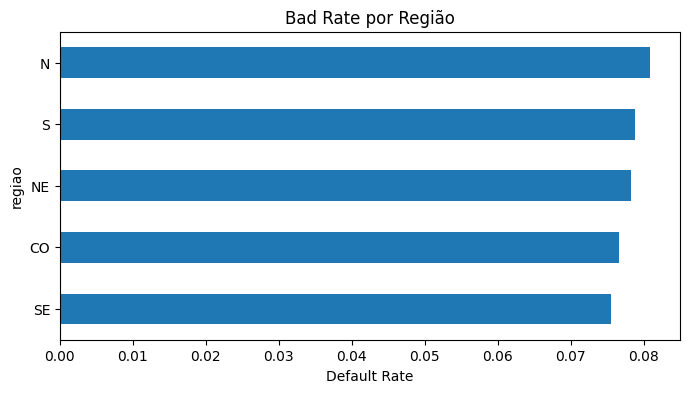

In [9]:
# [ORIGINAL — célula 14]

# Reimportação redundante (o pyplot já foi importado no setup). Inofensiva; mantida
# para preservar o código original.
import matplotlib.pyplot as plt

# Bad rate por região, ordenada. Serve para ver se a região discrimina risco — mas sem
# intervalo de confiança não dá para saber se as diferenças são reais ou ruído
# (a célula ✅ seguinte faz esse teste).
(
    df.groupby("regiao")["default"]
    .mean()
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8,4)
    )
)

# Título e rótulo do eixo.
plt.title(
    "Bad Rate por Região"
)
plt.xlabel("Default Rate")
plt.show()

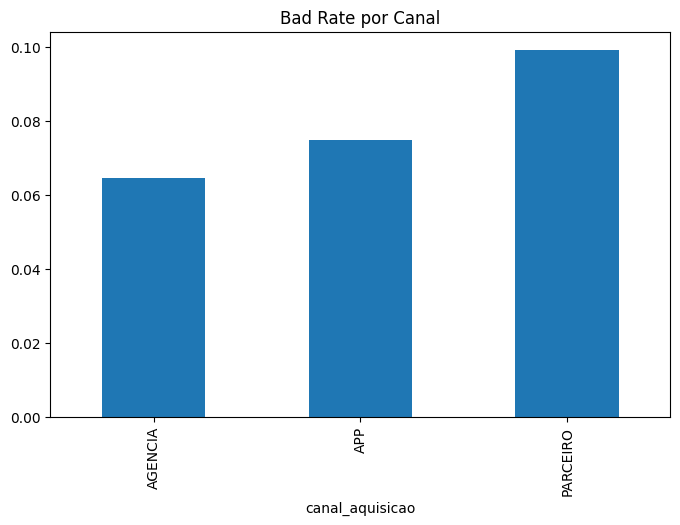

In [10]:
# [ORIGINAL — célula 20]

# Bad rate por canal de aquisição: o canal reflete o PERFIL de cliente que cada canal
# atrai (seleção), não necessariamente um efeito causal do canal em si.
(
    df.groupby("canal_aquisicao")
    ["default"]
    .mean()
    .sort_values()
    .plot(
        kind="bar",
        figsize=(8,5)
    )
)

# Título e exibição.
plt.title(
    "Bad Rate por Canal"
)
plt.show()

In [11]:
# ✅ Correção P6 — bad rate por categoria NO TREINO, com IC e teste de significância.

# Para cada variável categórica: bad rate, IC de Wilson e teste qui-quadrado. O teste
# responde "as diferenças entre categorias são maiores do que o acaso produziria?".
for col in FEATS_CAT:
    t = treino.groupby(col)["default"].agg(n="size", maus="sum")
    t["bad_rate"] = t["maus"] / t["n"]
    t["ic_inf"], t["ic_sup"] = wilson_ic(t["maus"], t["n"])
    p_val = stats.chi2_contingency(pd.crosstab(treino[col], treino["default"]))[1]
    print(f"\n{col}: qui-quadrado p-valor = {p_val:.2e}")
    display(t.style.format({"bad_rate": "{:.2%}", "ic_inf": "{:.2%}", "ic_sup": "{:.2%}"}))


regiao: qui-quadrado p-valor = 5.56e-01


,n,maus,bad_rate,ic_inf,ic_sup
regiao,,,,,
CO,1381,109,7.89%,6.58%,9.43%
N,910,66,7.25%,5.74%,9.12%
NE,3301,264,8.00%,7.12%,8.97%
S,2652,217,8.18%,7.20%,9.29%
SE,6714,491,7.31%,6.71%,7.96%



canal_aquisicao: qui-quadrado p-valor = 4.53e-08


,n,maus,bad_rate,ic_inf,ic_sup
canal_aquisicao,,,,,
AGENCIA,3649,238,6.52%,5.77%,7.37%
APP,8314,606,7.29%,6.75%,7.87%
PARCEIRO,2995,303,10.12%,9.09%,11.25%


**Leitura.** A região **não** tem efeito no mecanismo verdadeiro, e o teste confirma: o p-valor é alto e os intervalos se sobrepõem. O gráfico original de região, sem IC, **convida a uma conclusão falsa** ("a região X é mais arriscada"). Já o canal PARCEIRO tem efeito real (+0,45 no log-odds), e o teste o detecta com folga.

**Associação não é causalidade:** mesmo o efeito do canal é uma **associação** nos dados. Numa base real, o canal PARCEIRO pode ter bad rate maior porque atrai clientes mais frágeis (seleção), e não porque "entrar pelo parceiro causa default". Isso importa para a decisão: fechar o canal muda a composição da carteira; exigir mais do cliente que chega pelo canal é outra política, com outro efeito.

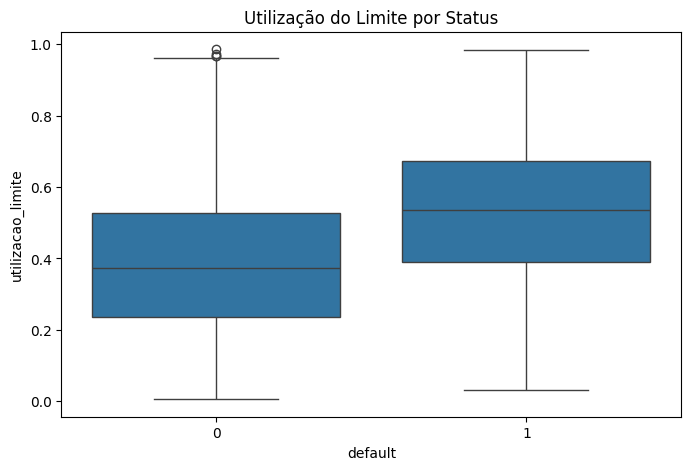

In [12]:
# [ORIGINAL — célula 15]

# Reimportação do seaborn (já importado no setup). Mantida para preservar o original.
import seaborn as sns

# Boxplot da utilização por status de default: compara a distribuição da variável
# entre bons (0) e maus (1). Uma separação visível sugere poder discriminante — é a
# versão visual do KS univariado.
plt.figure(figsize=(8,5))
sns.boxplot(
    x="default",
    y="utilizacao_limite",
    data=df
)

# Título e exibição.
plt.title(
    "Utilização do Limite por Status"
)
plt.show()

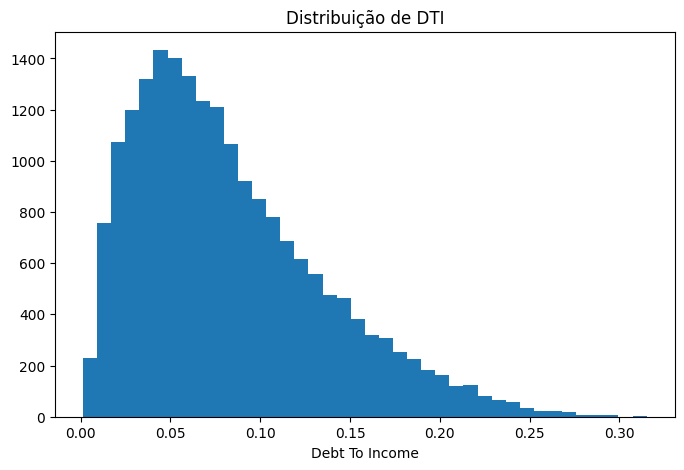

In [13]:
# [ORIGINAL — célula 16]

# Histograma do DTI: verifica assimetria, concentração e valores extremos. Em crédito,
# DTI alto = renda comprometida com dívida = menor capacidade de absorver imprevistos.
plt.figure(figsize=(8,5))
plt.hist(
    df["dti"],
    bins=40
)

# Título, rótulo e exibição.
plt.title(
    "Distribuição de DTI"
)
plt.xlabel("Debt To Income")
plt.show()

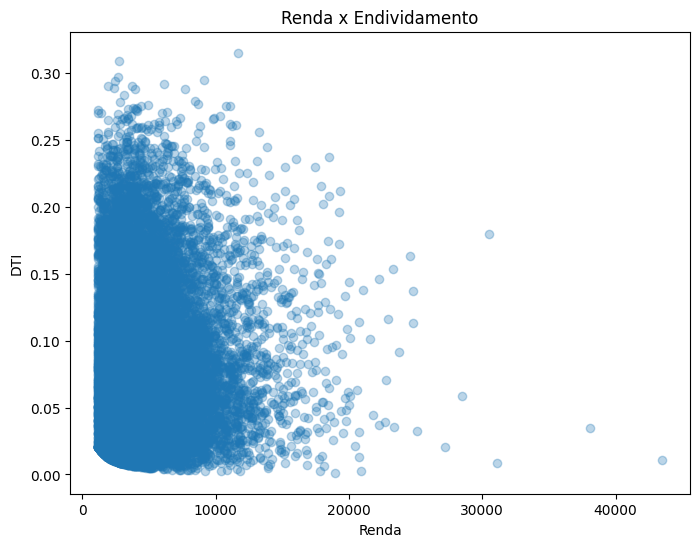

In [14]:
# [ORIGINAL — célula 17]

# Dispersão renda × DTI. O formato "hiperbólico" não é um achado empírico: é
# consequência da própria fórmula (dti = ead / (12 × renda)), ou seja, as duas
# variáveis são matematicamente dependentes.
plt.figure(figsize=(8,6))
plt.scatter(
    df["renda_mensal"],
    df["dti"],
    alpha=0.3
)

# Rótulos, título e exibição.
plt.xlabel("Renda")
plt.ylabel("DTI")
plt.title(
    "Renda x Endividamento"
)
plt.show()

C:\Users\gugaa\AppData\Local\Temp\ipykernel_24156\1105808476.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("atrasos_bucket")


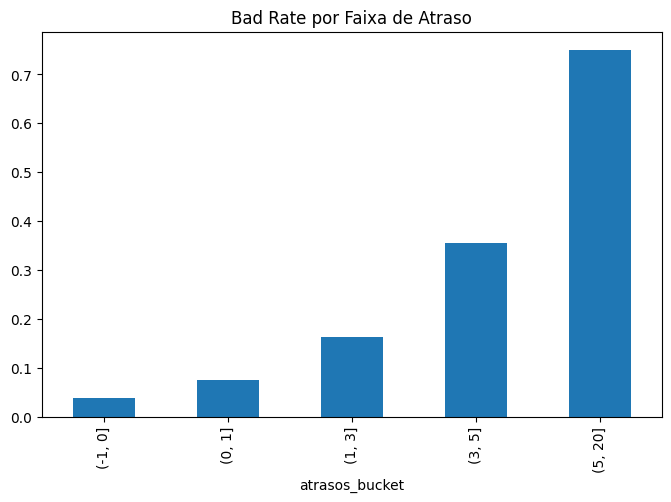

In [15]:
# [ORIGINAL — célula 18]

# Cópia da base para criar colunas auxiliares sem alterar df.
tmp = df.copy()

# Faixas de atraso (0, 1, 2–3, 4–5, 6+): transformar uma contagem em faixas revela se a
# relação com o default é monotônica (esperado: mais atrasos ⇒ mais default).
tmp["atrasos_bucket"] = pd.cut(
    tmp["atrasos_12m"],
    bins=[-1,0,1,3,5,20]
)

# Bad rate por faixa. Faixas com poucos clientes (6+ atrasos) têm taxa instável —
# de novo, falta o IC para saber o quanto confiar em cada barra.
(
    tmp.groupby("atrasos_bucket")
    ["default"]
    .mean()
    .plot(
        kind="bar",
        figsize=(8,5)
    )
)

# Título e exibição.
plt.title(
    "Bad Rate por Faixa de Atraso"
)
plt.show()

C:\Users\gugaa\AppData\Local\Temp\ipykernel_24156\1092639840.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("idade_bucket")


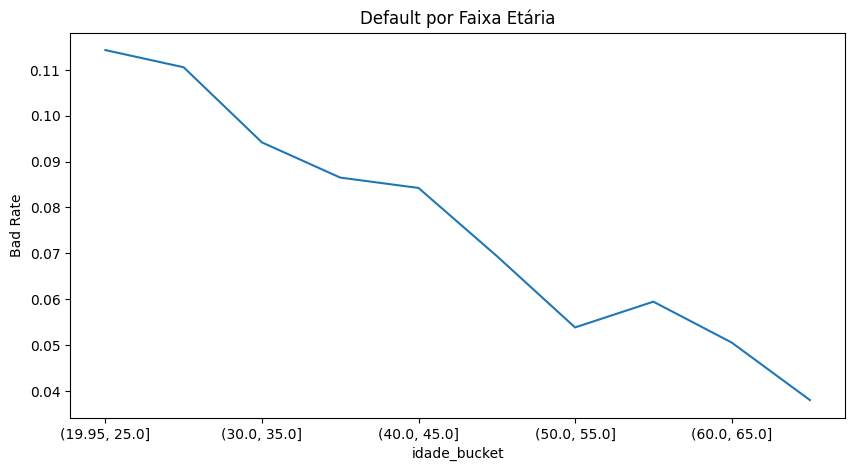

In [16]:
# [ORIGINAL — célula 22]

# Nova cópia da base para a análise de idade.
tmp = df.copy()

# 10 faixas de idade de MESMA LARGURA. Alternativa melhor em crédito: faixas por
# quantis (mesmo nº de clientes por faixa), que dão bad rates com precisão parecida.
tmp["idade_bucket"] = pd.cut(
    tmp["idade"],
    bins=10
)

# Bad rate por faixa etária, em linha: verifica se o efeito é monotônico (aqui é,
# pois o mecanismo verdadeiro é linear na idade) ou em "U" (comum em dados reais).
(
    tmp.groupby("idade_bucket")
    ["default"]
    .mean()
    .plot(
        figsize=(10,5)
    )
)

# Título, rótulo e exibição.
plt.title(
    "Default por Faixa Etária"
)
plt.ylabel("Bad Rate")
plt.show()

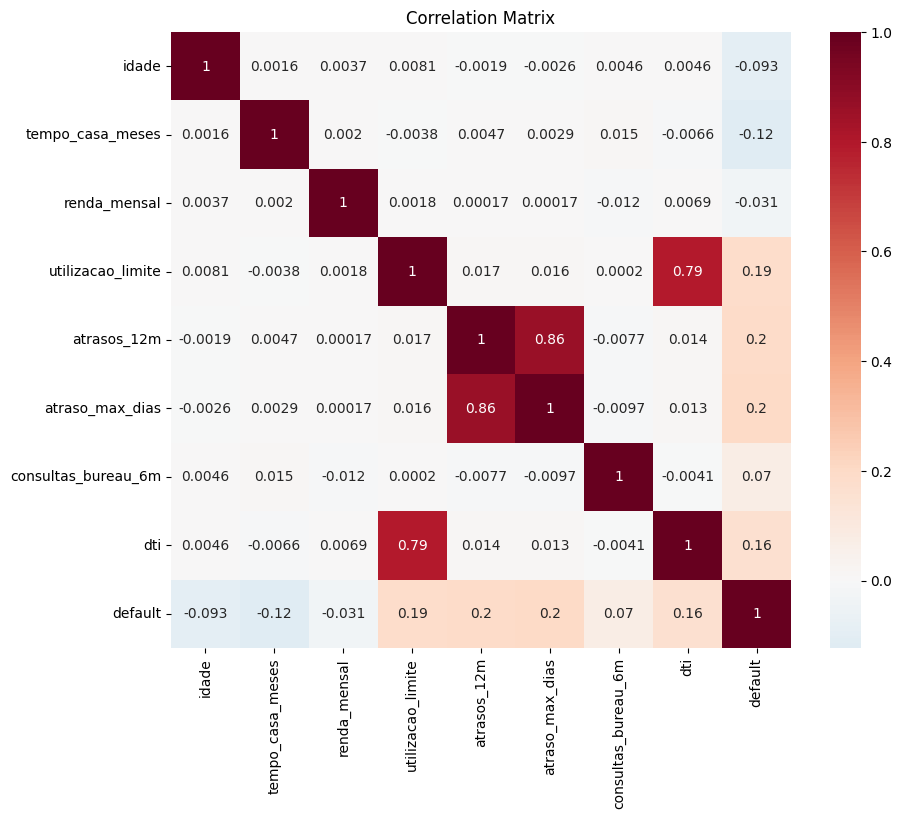

In [17]:
# [ORIGINAL — célula 19]

# Reimportação do seaborn (redundante, mantida).
import seaborn as sns

# Matriz de correlação de Pearson entre numéricas e o target. Serve para dois fins:
# (1) detectar variáveis redundantes (multicolinearidade) e (2) ter uma primeira ideia
# do poder preditivo. Limitação: Pearson só mede relação LINEAR e é sensível a caudas
# (renda é muito assimétrica); Spearman (por postos) é mais robusto.
corr = df[
    [
        "idade",
        "tempo_casa_meses",
        "renda_mensal",
        "utilizacao_limite",
        "atrasos_12m",
        "atraso_max_dias",
        "consultas_bureau_6m",
        "dti",
        "default"
    ]
].corr()

# Mapa de calor com escala divergente centrada em zero (vermelho = correlação
# positiva, azul = negativa).
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

# Título e exibição.
plt.title(
    "Correlation Matrix"
)
plt.show()

### Missing values, outliers e multicolinearidade — o que a EDA original não olhou

**Missing values.** Um valor ausente em crédito raramente é "só um buraco":
- **Por que existe:** cliente não informou (renda), dado não se aplica (sem histórico no bureau), falha de integração.
- **Pode ter significado de negócio:** "não informou a renda" costuma ser um sinal de risco por si só (*missing not at random*).
- **Quando imputar é perigoso:** imputar a mediana num missing informativo coloca clientes arriscados no perfil médio — o modelo **subestima** o risco deles e introduz **viés**.
- **Boa prática:** comparar a bad rate de quem tem e de quem não tem o dado; imputar **dentro do pipeline** (a mediana aprendida só no treino) e **acrescentar uma flag de missing**.

**Outliers.**
- **Por que existem:** erro de digitação/integração (renda de R$ 1 milhão por um zero a mais), ou comportamento **real** e raro (um cliente de alta renda, um atraso de 180 dias).
- **Erro ou comportamento real?** Erro se viola uma regra de domínio (idade 250, utilização negativa); real se é plausível. Os reais **não devem ser apagados**: frequentemente são os clientes mais informativos para o risco.
- **Modelos lineares (logística):** um valor extremo pode dominar o coeficiente e distorcer o efeito para todos os demais ⇒ usar **log**, **winsorização** (cortar nos percentis 1/99 aprendidos no treino) ou faixas (WoE).
- **Árvores/boosting:** robustos a outliers nas features — as divisões dependem só da ordem dos valores, não da distância.
- **Nesta base:** o gerador já aplica `clip` (renda entre 1.200 e 60.000, EAD ≥ 300, DTI ≤ 3). O clip cria **massas artificiais** nos limites (célula abaixo), algo a reconhecer num histograma real (picos exatamente no piso ou no teto costumam indicar truncamento na origem).

**Multicolinearidade.** Várias variáveis desta base são funções umas das outras: `ead = limite × utilização`, `dti = ead / (12 × renda)` e `atraso_max ≈ atrasos × dias`. Para o boosting isso quase não afeta a performance, mas **divide a importância** entre variáveis redundantes (e a interpretação fica enganosa). Para a logística, torna os coeficientes **instáveis** e pode **inverter sinais** (veremos a renda com sinal "errado" na seção 5).

In [18]:
# ✅ Correção P6 / P2 / P7 — missing, outliers e multicolinearidade, NO TREINO.

# (1) MISSING: a ausência da renda está associada ao default? Se sim, a flag de missing
# é uma feature valiosa; se não (caso MCAR, simulado aqui), a imputação é quase neutra.
falta = treino["renda_mensal"].isna()
print(f"Renda ausente: {falta.mean():.2%} do treino | bad rate sem renda {treino.loc[falta, 'default'].mean():.2%} "
      f"× com renda {treino.loc[~falta, 'default'].mean():.2%}")
# O DTI existe mesmo para quem não tem renda — inconsistência do gerador (P2).
print(f"DTI preenchido entre os clientes SEM renda: {treino.loc[falta, 'dti'].notna().mean():.0%}")

# (2) OUTLIERS / truncamentos: quantos clientes estão exatamente nos pisos e tetos do
# gerador. Massa num único valor extremo é sinal de truncamento (e não de dado natural).
limites = {"renda_mensal == 1200 (piso)": (treino["renda_mensal"] == 1200).sum(),
           "ead == 300 (piso)": (treino["ead"] == 300).sum(),
           "dti == 3 (teto)": (treino["dti"] == 3).sum(),
           "atraso_max_dias == 180 (teto)": (treino["atraso_max_dias"] == 180).sum()}
print("\nClientes nos limites de truncamento:", limites)
display(treino[FEATS_NUM].describe(percentiles=[.01, .5, .99]).T[["min", "1%", "50%", "99%", "max"]])

# (3) MULTICOLINEARIDADE: correlação de Spearman (robusta a caudas e a relações não
# lineares monotônicas) e VIF = 1 / (1 − R²) de cada variável explicada pelas demais.
# Regra prática: VIF > 5 merece atenção; VIF > 10 indica redundância forte.
sp = treino[FEATS_NUM].corr(method="spearman")
pares = sp.where(np.triu(np.ones(sp.shape, dtype=bool), 1)).stack()
print("\nPares com |Spearman| > 0,5:")
print(pares[pares.abs() > 0.5].round(2).to_string())
Xv = treino[FEATS_NUM].dropna()
vif = {c: 1 / (1 - LinearRegression().fit(Xv.drop(columns=c), Xv[c]).score(Xv.drop(columns=c), Xv[c])) for c in FEATS_NUM}
print("\nVIF:", {k: round(v, 1) for k, v in sorted(vif.items(), key=lambda kv: -kv[1])})

Renda ausente: 3.88% do treino | bad rate sem renda 6.88% × com renda 7.70%
DTI preenchido entre os clientes SEM renda: 100%

Clientes nos limites de truncamento: {'renda_mensal == 1200 (piso)': np.int64(191), 'ead == 300 (piso)': np.int64(175), 'dti == 3 (teto)': np.int64(0), 'atraso_max_dias == 180 (teto)': np.int64(1)}


,min,1%,50%,99%,max
idade,20.000,20.000,45.000,70.000,70.000
tempo_casa_meses,1.000,2.000,61.000,119.000,120.000
renda_mensal,"1,200.000","1,200.000","4,047.510","14,764.913","43,469.130"
utilizacao_limite,0.006,0.044,0.385,0.857,0.984
atrasos_12m,0.000,0.000,1.000,3.000,6.000
atraso_max_dias,0.000,0.000,9.000,90.000,180.000
n_produtos,1.000,1.000,3.000,6.000,6.000
consultas_bureau_6m,0.000,0.000,1.000,4.000,8.000
dti,0.001,0.009,0.072,0.232,0.315
limite_aprovado,"1,202.590","1,997.202","9,574.690","42,356.284","94,486.220"



Pares com |Spearman| > 0,5:
renda_mensal       limite_aprovado   0.810
utilizacao_limite  dti               0.810
atrasos_12m        atraso_max_dias   0.930

VIF: {'limite_aprovado': 7.7, 'dti': 6.5, 'renda_mensal': 6.3, 'utilizacao_limite': 5.0, 'atrasos_12m': 3.9, 'atraso_max_dias': 3.9, 'consultas_bureau_6m': 1.0, 'n_produtos': 1.0, 'idade': 1.0, 'tempo_casa_meses': 1.0}


### 🔴 P7 — Variáveis redundantes (multicolinearidade) não analisadas

- **Problema:** `atraso_max_dias` é quase uma cópia de `atrasos_12m` (Spearman ≈ 0,93); `dti`, `limite_aprovado`, `utilizacao_limite` e `renda_mensal` estão ligadas por identidades (VIFs entre ~4 e ~8).
- **Por que é um problema:** na logística, coeficientes de variáveis correlacionadas ficam instáveis (pequenas mudanças nos dados mudam muito os coeficientes) e podem ter o **sinal trocado**, tornando a explicação ao regulador impossível. No boosting, a importância é **dividida** entre as redundantes, e o ranking de importância engana.
- **Impacto:** interpretação errada dos drivers de risco; modelos menos estáveis ao longo do tempo.
- **Correção:** escolher uma variável por "conceito" (ex.: manter `atrasos_12m` **ou** uma combinação como "atraso médio por ocorrência"), preferir razões com significado de negócio (DTI, utilização) às variáveis brutas que as compõem, e monitorar o VIF na seleção de variáveis de modelos lineares.

## 5. Modelagem

### O que o notebook faz
1. **Pré-processamento** (`ColumnTransformer`): mediana nas numéricas e one-hot nas categóricas.
2. **Modelo**: LightGBM com 400 árvores.
3. **Calibração**: `CalibratedClassifierCV(method="isotonic", cv=3)` — treina 3 cópias do pipeline em 2/3 do treino cada e ajusta, em cada 1/3 restante, uma função que corrige a escala das probabilidades; a PD final é a média das 3.

> 🟢 **Correto:** a imputação e o encoding estão **dentro do Pipeline**, que por sua vez está dentro da calibração. Assim a mediana é aprendida só com os dados de treino de cada dobra, e **não há pré-processamento antes do split** (um dos vazamentos mais comuns: calcular médias/medianas ou escalas na base inteira antes de separar treino e teste).
>
> 🟢 **Correto:** `handle_unknown="ignore"` evita que uma categoria nova em produção (ex.: um canal novo) derrube a escoragem.
>
> 🟢 **Correto:** calibrar a PD. Em crédito, a probabilidade **é o produto** (vai para precificação e perda esperada), então ela precisa estar na escala certa.

### Como funciona o LightGBM (gradient boosting de árvores)
- **Mecanismo:** constrói árvores de decisão **em sequência**; cada nova árvore é treinada para corrigir os erros (gradientes da log loss) das anteriores. A previsão final é a soma das árvores, convertida em probabilidade pela função logística.
- **Não linearidades:** cada árvore divide as variáveis em faixas ("utilização > 0,7 e atrasos ≥ 2"), então curvas, degraus (como o efeito de `renda > 9000`) e **interações** são aprendidos sem precisar criá-los à mão.
- **Por que é usado em crédito:** é o padrão para dados tabulares; costuma ganhar da logística quando há interações e não linearidades fortes e muitos dados.
- **Limitações:** interpretabilidade só **pós-hoc** (SHAP, permutação); mais sensível a *overfitting* e a drift de interações; mais difícil de explicar a regulador e cliente.
- **Risco de overfitting:** alto quando há muitas árvores, folhas grandes (`num_leaves`) e pouca regularização. Com 400 árvores, 31 folhas e `learning_rate` 0,05 **sem early stopping**, o modelo pode decorar o treino — é o que vamos medir.
- **Importância de features:** o LightGBM oferece importância por nº de divisões (`split`, o padrão) ou por ganho (`gain`). Ambas são enviesadas e descrevem **o modelo**, não o mundo (seção 12).

### Calibração isotônica
A calibração isotônica ajusta uma função **em degraus e monotônica** que mapeia o score do modelo para a frequência observada de default. É flexível (corrige qualquer distorção monotônica), mas precisa de muitos dados em cada dobra (aqui ~5 mil clientes e ~380 defaults por dobra, no limite do razoável) e produz **empates** (muitos clientes com exatamente a mesma PD). A alternativa paramétrica é o **Platt/sigmoide** (`method="sigmoid"`), mais estável com pouca amostra.

> 🟡 **Atenção:** `cv=3` usa dobras **aleatórias** (estratificadas) dentro do treino. Como as safras aqui são sorteadas, isso é aceitável; com dados reais, a calibração deveria ser ajustada numa janela **mais recente** (ex.: as últimas safras), para refletir o nível de risco atual.

In [19]:
# [ORIGINAL — célula 4]

# Pré-processamento por tipo de coluna.
pre = ColumnTransformer([
    # Numéricas: mediana no lugar do missing. A mediana é robusta a caudas longas
    # (renda) — melhor que a média. Falta a flag de missing (add_indicator=True), que
    # deixaria o modelo aprender se "não informou a renda" é um sinal de risco (P2).
    ("num", SimpleImputer(strategy="median"), FEATS_NUM),
    # Categóricas: one-hot. Categoria desconhecida em produção vira um vetor de zeros
    # em vez de erro (robustez operacional).
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATS_CAT),
])

# LightGBM com hiperparâmetros fixos (não houve tuning nem early stopping):
# 400 árvores × learning rate 0,05 × até 31 folhas por árvore = modelo com muita
# capacidade para uma base de ~15 mil linhas e ~1.150 defaults.
# min_child_samples=40: cada folha precisa de 40 clientes (alguma regularização).
# subsample=0.9: pretende usar 90% das linhas por árvore, MAS no LightGBM isso só é
# ativado com subsample_freq > 0 — como subsample_freq não foi definido, o
# parâmetro é IGNORADO (ver P8).
# colsample_bytree=0.9: cada árvore sorteia 90% das features (esse funciona).
lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    min_child_samples=40, subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, verbose=-1,
)

# Pipeline pré-processamento + modelo: um único objeto que recebe dados brutos e
# devolve probabilidades — o mesmo objeto é usado no treino e na escoragem.
base_model = Pipeline([("pre", pre), ("clf", lgbm)])

# Calibração isotônica com validação cruzada de 3 dobras. O pipeline inteiro é
# clonado e re-treinado dentro de cada dobra, então a calibração nunca vê as linhas
# que o modelo usou para aprender (evita calibrar em dados "decorados").
modelo = CalibratedClassifierCV(base_model, method="isotonic", cv=3)
# Treino apenas com as safras de treino (o OOT continua intocado nesta etapa).
modelo.fit(X_tr, y_tr)

# predict_proba devolve [P(classe 0), P(classe 1)]; a coluna 1 é a probabilidade de
# default. Por ter passado pela calibração, ela é tratada daqui em diante como PD.
pd_oot = modelo.predict_proba(X_oot)[:, 1]
print("Modelo treinado e calibrado.")

Modelo treinado e calibrado.


### 🔴 P8 — `subsample=0.9` não tem efeito (bug de configuração)

- **Problema:** no LightGBM, o *bagging* de linhas (`subsample` / `bagging_fraction`) só é ativado se `subsample_freq` (`bagging_freq`) for maior que zero. O padrão é 0, então o parâmetro é **ignorado em silêncio** (com `verbose=-1`, nem o aviso aparece).
- **Por que é um problema:** quem lê o código acredita que há uma regularização que não existe; hiperparâmetros documentados diferentes dos efetivos são um achado típico de validação de modelos.
- **Impacto:** o modelo é **idêntico** a um treinado sem `subsample` (provado na célula abaixo) — menos regularizado do que o autor pretendia.
- **Correção:** `LGBMClassifier(..., subsample=0.8, subsample_freq=1)`.

### 🔴 P9 — Sem baseline, sem diagnóstico de overfitting e sem tuning

- **Problema:** o notebook treina **um único modelo**, com hiperparâmetros fixos, sem comparar com um **baseline** (logística ou scorecard) e sem olhar a performance **no treino** para diagnosticar overfitting.
- **Por que é um problema:** sem baseline não há como saber se a complexidade do boosting **se paga**; sem comparar treino e teste não há como saber se o modelo **decorou** o treino.
- **Impacto:** medido abaixo — o LightGBM original tem AUC ≈ 0,99 no treino e ≈ 0,78 no OOT (overfitting severo), e uma logística simples **supera** o modelo original.
- **Correção:** (i) sempre treinar o baseline logístico; (ii) reportar AUC de treino × validação; (iii) regularizar o boosting (menos folhas, mais amostras por folha, `reg_lambda`, bagging ativado) e escolher hiperparâmetros **na validação temporal**, nunca no OOT.

In [20]:
# ✅ Correção P8 / P9 — diagnóstico: o subsample é ignorado? há overfitting?

# (a) Treina o pipeline original SEM calibração, sem subsample e com subsample ativado.
# clone() garante que os objetos do notebook original não sejam alterados.
p_orig_raw = clone(base_model).fit(X_tr, y_tr)
sem_sub = Pipeline([("pre", clone(pre)), ("clf", clone(lgbm).set_params(subsample=1.0))]).fit(X_tr, y_tr)
com_sub = Pipeline([("pre", clone(pre)), ("clf", clone(lgbm).set_params(subsample_freq=1))]).fit(X_tr, y_tr)
# Se subsample=0.9 fosse efetivo, as previsões do original seriam diferentes das do
# modelo com subsample=1.0. Iguais ⇒ o parâmetro não fez nada.
print("Previsões idênticas ao modelo SEM subsample:",
      np.allclose(p_orig_raw.predict_proba(X_oot)[:, 1], sem_sub.predict_proba(X_oot)[:, 1]))
print("Previsões idênticas ao modelo COM subsample_freq=1:",
      np.allclose(p_orig_raw.predict_proba(X_oot)[:, 1], com_sub.predict_proba(X_oot)[:, 1]))

# (b) Overfitting: AUC no treino × no OOT do modelo original (calibrado e sem calibrar).
# Gap grande = o modelo aprendeu particularidades do treino que não se repetem.
diag = pd.DataFrame({
    "AUC treino": [roc_auc_score(y_tr, p_orig_raw.predict_proba(X_tr)[:, 1]),
                   roc_auc_score(y_tr, modelo.predict_proba(X_tr)[:, 1])],
    "AUC OOT": [roc_auc_score(y_oot, p_orig_raw.predict_proba(X_oot)[:, 1]),
                roc_auc_score(y_oot, pd_oot)]},
    index=["LightGBM original (sem calibração)", "LightGBM original + isotônica (modelo do notebook)"])
diag["gap"] = diag["AUC treino"] - diag["AUC OOT"]
diag

Previsões idênticas ao modelo SEM subsample: True
Previsões idênticas ao modelo COM subsample_freq=1: False


,AUC treino,AUC OOT,gap
LightGBM original (sem calibração),0.994,0.781,0.213
LightGBM original + isotônica (modelo do notebook),0.996,0.783,0.213


### Baseline: regressão logística

A regressão logística modela o **log-odds** do default como uma soma ponderada das variáveis:

$$\log\frac{PD}{1-PD} = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k \quad\Longleftrightarrow\quad PD = \frac{1}{1+e^{-(\beta_0+\sum\beta_j x_j)}}$$

- **Odds** = PD / (1 − PD). PD de 20% ⇒ odds de 0,25 ("1 mau para 4 bons").
- **Log-odds** = log das odds; é a escala em que o modelo é linear.
- **Coeficiente β:** quanto o log-odds muda quando a variável sobe 1 unidade (aqui, 1 desvio-padrão, porque padronizamos), **mantidas as demais constantes**.
- **Odds ratio = e^β:** fator que multiplica as odds. β = 0,6 ⇒ odds × 1,82 (+82%). Atenção: multiplicar as odds **não** é multiplicar a PD — para PD pequena é quase a mesma coisa; para PD alta, não.
- **Sinal:** β > 0 aumenta o risco; β < 0 reduz. O sinal precisa fazer **sentido de negócio**; um sinal contraintuitivo é um alerta de multicolinearidade, de variável mal construída ou de leakage.
- **Ligação com a PD:** a saída da logística já é uma probabilidade, e o treino por máxima verossimilhança (log loss) tende a produzi-la **bem calibrada** — por isso ela é o benchmark natural em crédito, junto com o scorecard.

In [21]:
# ✅ Correção P9 — baseline logístico (treino em jan–jun, avaliação na validação jul–set).

# Ajusta a logística com flag de missing e padronização.
logit_dev = pipeline_logistica().fit(X_fit, y_fit)
p_val_lr = logit_dev.predict_proba(X_val)[:, 1]
print(f"Logística — AUC treino {roc_auc_score(y_fit, logit_dev.predict_proba(X_fit)[:, 1]):.4f} | "
      f"AUC validação {roc_auc_score(y_val, p_val_lr):.4f}")

# Coeficientes em log-odds por +1 desvio-padrão e o odds ratio correspondente.
nomes_lr = logit_dev.named_steps["pre"].get_feature_names_out()
coefs = pd.DataFrame({"beta (log-odds por +1 DP)": logit_dev.named_steps["clf"].coef_[0]}, index=nomes_lr)
coefs["odds ratio = e^beta"] = np.exp(coefs.iloc[:, 0])
coefs.sort_values(coefs.columns[0], key=abs, ascending=False)

Logística — AUC treino 0.8186 | AUC validação 0.8242


,beta (log-odds por +1 DP),odds ratio = e^beta
cat__canal_aquisicao_AGENCIA,-0.853,0.426
cat__canal_aquisicao_APP,-0.782,0.458
num__utilizacao_limite,0.571,1.770
num__tempo_casa_meses,-0.515,0.597
cat__regiao_SE,-0.495,0.610
num__atrasos_12m,0.441,1.554
cat__regiao_N,-0.430,0.650
cat__regiao_CO,-0.407,0.666
cat__regiao_NE,-0.401,0.670
num__idade,-0.398,0.672


**Como ler os coeficientes.**
- `utilizacao_limite`, `atrasos_12m`, `consultas_bureau_6m`, `atraso_max_dias` e `dti` têm β > 0 (aumentam o risco); `tempo_casa_meses`, `idade` e `n_produtos` têm β < 0 — todos coerentes com o negócio e com o mecanismo verdadeiro.
- **`renda_mensal` com sinal contraintuitivo ou perto de zero:** no mecanismo verdadeiro, renda alta **reduz** o risco (degrau em R$ 9.000). O efeito da renda está "espalhado" entre `renda_mensal`, `limite_aprovado` (≈ renda × fator) e `dti` (÷ renda): é a **multicolinearidade** (P7) confundindo a leitura de cada coeficiente isolado. O modelo prevê bem, mas explicar "o efeito da renda" olhando um único β seria errado.
- As categóricas usam one-hot **sem categoria de referência** (com regularização L2, o que importa é a **diferença** entre os β das categorias): PARCEIRO tem o maior β entre os canais, como no mecanismo verdadeiro. Já a região S aparece com β ~0,3 acima da SE, **embora a região não tenha efeito nenhum** no mecanismo: é ruído amostral que o modelo aprendeu. Variáveis sem sinal estatístico (qui-quadrado p = 0,56 na seção 4) deveriam sair do modelo.
- **Associação, não causa:** β mede a associação condicional nos dados. "Consultas ao bureau aumentam o risco" não significa que proibir consultas reduziria o default: a consulta é **sintoma** da necessidade de crédito.

In [22]:
# ✅ Correção P9 — comparação de candidatos NA VALIDAÇÃO TEMPORAL (o OOT continua intocado).

# LightGBM regularizado: árvores rasas, folhas com mais clientes, L2 e bagging ATIVADO.
def lgbm_regularizado(num_leaves):
    return Pipeline([("pre", clone(pre)),
                     ("clf", LGBMClassifier(n_estimators=300, learning_rate=0.05 if num_leaves <= 4 else 0.03,
                                            num_leaves=num_leaves, min_child_samples=100, reg_lambda=5.0,
                                            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                            random_state=RANDOM_STATE, verbose=-1))])

# Candidatos: o procedimento original, o LightGBM original sem calibração, a logística e
# duas versões regularizadas do LightGBM (com e sem a calibração isotônica).
candidatos = {
    "LightGBM original + isotônica (procedimento do notebook)": CalibratedClassifierCV(clone(base_model), method="isotonic", cv=3),
    "LightGBM original, sem calibração": clone(base_model),
    "Regressão logística (baseline)": pipeline_logistica(),
    "LightGBM regularizado (4 folhas)": lgbm_regularizado(4),
    "LightGBM regularizado (8 folhas)": lgbm_regularizado(8),
    "LightGBM regularizado (4 folhas) + isotônica": CalibratedClassifierCV(lgbm_regularizado(4), method="isotonic", cv=3),
}
# Treina cada candidato em jan–jun e guarda a PD de jul–set.
P_VAL = {nome: m.fit(X_fit, y_fit).predict_proba(X_val)[:, 1] for nome, m in candidatos.items()}
AUC_TREINO = {nome: roc_auc_score(y_fit, m.predict_proba(X_fit)[:, 1]) for nome, m in candidatos.items()}

# Tabela de validação: ordenação (AUC), qualidade probabilística (log loss, Brier) e nível
# (PD média × taxa real). Critério de escolha: log loss (a métrica que avalia a PD
# inteira), com o AUC como segunda leitura.
tab_val = pd.DataFrame({nome: {"AUC treino": AUC_TREINO[nome], "AUC validação": roc_auc_score(y_val, p),
                               "Log loss": log_loss(y_val, p), "Brier": brier_score_loss(y_val, p),
                               "PD média": p.mean(), "Taxa real": y_val.mean()}
                        for nome, p in P_VAL.items()}).T.sort_values("Log loss")
tab_val.style.format({"AUC treino": "{:.4f}", "AUC validação": "{:.4f}", "Log loss": "{:.4f}", "Brier": "{:.5f}",
                      "PD média": "{:.2%}", "Taxa real": "{:.2%}"})

,AUC treino,AUC validação,Log loss,Brier,PD média,Taxa real
Regressão logística (baseline),0.8186,0.8242,0.2152,0.05968,7.68%,7.81%
LightGBM regularizado (4 folhas),0.8474,0.8252,0.2167,0.06038,7.65%,7.81%
LightGBM regularizado (8 folhas),0.8668,0.8235,0.2171,0.06037,7.65%,7.81%
LightGBM regularizado (4 folhas) + isotônica,0.8487,0.8246,0.2236,0.06061,7.74%,7.81%
LightGBM original + isotônica (procedimento do notebook),0.9994,0.8013,0.2281,0.06321,7.78%,7.81%
"LightGBM original, sem calibração",0.9995,0.7926,0.2419,0.06427,6.11%,7.81%


**Leitura (validação temporal, jul–set/2024).**
- As duas versões do **LightGBM original** têm AUC de treino ≈ 1,0 e os piores AUC e log loss da validação: é **overfitting**. A calibração isotônica corrige o nível da PD (de 6,1% para 7,8%, contra 7,8% de taxa real) e melhora um pouco o AUC (a média dos 3 modelos das dobras funciona como um pequeno ensemble), mas não fecha a distância para os modelos regularizados.
- A **logística** e o **LightGBM regularizado** ficam praticamente empatados no topo. Isso não é coincidência: o mecanismo verdadeiro é **linear no log-odds**, e um modelo linear já está "na forma certa". O boosting só consegue empatar quando é contido.
- Aplicar a calibração isotônica **por cima** do LightGBM regularizado **piora** a log loss: um boosting bem regularizado, treinado com log loss, já sai calibrado, e a isotônica em dobras pequenas adiciona degraus e variância. **Calibrar não é obrigatório — é uma correção a ser medida.**

**Decisão (tomada aqui, na validação):** com desempenho empatado, a **logística** é a campeã (interpretável, estável, fácil de implementar e de explicar ao regulador); o **LightGBM regularizado (4 folhas)** fica como *challenger*. A comparação honesta de ambos com o modelo original é feita **uma única vez** no OOT, na seção 13.

### 🟡 Underfitting × overfitting
O **overfitting** aparece como gap grande treino–validação (modelo original). O **underfitting** apareceria como AUC baixo **nos dois** conjuntos (modelo simples demais para o fenômeno). A logística tem gap pequeno e AUC alto — não está em underfitting porque o mundo simulado é quase linear. Em dados reais com não linearidades fortes, uma logística sem transformações (log, faixas/WoE, splines) poderia sofrer underfitting — e aí o boosting teria vantagem.

## 6. Avaliação — discriminação e calibração

Um modelo de PD é avaliado em **duas dimensões independentes**:

- **Discriminação (ordenação):** o modelo consegue separar clientes de maior e de menor risco? Se eu sortear um mau e um bom, o mau recebe PD maior? → **AUC/Gini, KS, PR-AUC**.
- **Calibração (nível):** as probabilidades correspondem às frequências observadas? → **curva de calibração, Brier, log loss, ECE, testes por faixa**.

Um modelo pode ordenar perfeitamente e estar mal calibrado (ex.: prevê o dobro da PD verdadeira para todos) — o AUC não muda, mas a perda esperada e o preço saem errados. **Exemplo de calibração:** se um grupo de 1.000 clientes recebe PD prevista de ~20%, um modelo bem calibrado implica que **cerca de 200** deles entram em default (com variação amostral: ±25 clientes, aproximadamente, num IC de 95%). Se entrarem 120, o modelo **superestima** o risco desse grupo; se entrarem 300, **subestima**.

| Métrica | O que mede | Leitura em crédito |
|---|---|---|
| **ROC-AUC** | Probabilidade de um mau aleatório ter PD maior que um bom aleatório | 0,5 = sorteio; 0,7–0,8 bom; > 0,8 muito bom para PF. **Só ordenação.** |
| **Gini** | 2·AUC − 1 | Mesma informação que o AUC, na escala preferida pelo mercado |
| **KS** | Maior distância entre as distribuições acumuladas de score de bons e maus | Separação máxima num ponto de corte; muito usado em comitês brasileiros |
| **PR-AUC** | Área sob precision × recall | Foca na classe rara; comparar com a prevalência (o valor de um modelo aleatório) |
| **Brier** | Média de (PD − y)² | Qualidade da probabilidade (calibração + discriminação); comparar com p(1−p) |
| **Log Loss** | −média[y·log(PD) + (1−y)·log(1−PD)] | Pune fortemente PDs confiantes e erradas; é a função que a logística otimiza |
| **ECE** | Distância média entre PD prevista e taxa observada por faixa | Medida direta de calibração |
| **Accuracy** | % de acertos num threshold | **Enganosa** com desbalanceamento (~92% "de graça") |
| **Precision** | Dos reprovados, % que seriam maus | Custo de reprovar bons clientes |
| **Recall (TPR)** | Dos maus, % que o modelo reprova | Quanto da perda o modelo evita |
| **Specificity (TNR)** | Dos bons, % aprovados | Negócio preservado |
| **FPR** | Dos bons, % reprovados (1 − specificity) | Receita perdida |
| **FNR** | Dos maus, % aprovados (1 − recall) | Perda que entra na carteira |
| **F1** | Média harmônica de precision e recall | Pesa os dois erros igualmente — raramente reflete a economia do crédito |

In [23]:
# [ORIGINAL — célula 5]

# KS: ordena os clientes pelo score, acumula a proporção de maus e de bons, e mede a
# maior distância entre as duas curvas. Quanto maior, melhor o modelo separa as
# populações em algum ponto de corte. É multiplicado por 100 (convenção de mercado).
def ks_score(y_true, y_score):
    # Tabela com o target e o score, ordenada do menor para o maior score.
    d = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(y_score)}).sort_values("s")
    # Proporção acumulada de maus e de bons até cada posição. O max(..., 1) evita divisão
    # por zero se não houver maus (ou bons) na amostra.
    bad  = (d["y"] == 1).cumsum() / max((d["y"] == 1).sum(), 1)
    good = (d["y"] == 0).cumsum() / max((d["y"] == 0).sum(), 1)
    # Maior diferença absoluta entre as duas acumuladas. Detalhe: ao percorrer linha a
    # linha, clientes com o MESMO score (comuns após a calibração isotônica) são
    # avaliados em posições intermediárias do empate; o KS correto só avalia cortes
    # entre scores distintos. A diferença aqui é pequena (44,14 × 44,12 — célula ✅).
    return float(np.max(np.abs(bad - good)) * 100)

# Gini = 2·AUC − 1: reescala o AUC para 0 (aleatório) a 1 (perfeito).
def gini_score(auc):
    return 2*auc - 1

# Métricas no OOT: AUC (ordenação), KS (separação máxima) e Brier (qualidade da
# probabilidade). Falta uma medida de calibração direta — ver P11.
auc   = roc_auc_score(y_oot, pd_oot)
ks    = ks_score(y_oot, pd_oot)
brier = brier_score_loss(y_oot, pd_oot)

# Relatório das métricas.
print(f"AUC   : {auc:.4f}")
print(f"Gini  : {gini_score(auc):.4f}")
print(f"KS    : {ks:.2f}")
print(f"Brier : {brier:.5f}")

# Régua de mercado para o KS. É uma HEURÍSTICA: o KS depende da população (carteiras
# mais homogêneas têm KS menor com o mesmo modelo) e de quantos clientes há; não é uma
# escala universal. Deve vir acompanhada de intervalo de confiança.
regua = "fraco" if ks < 30 else ("aceitavel" if ks < 40 else ("bom" if ks < 50 else "excelente"))
print(f"\nLeitura de mercado do KS: {regua}")

AUC   : 0.7832
Gini  : 0.5663
KS    : 44.14
Brier : 0.06469

Leitura de mercado do KS: bom


### 🔴 P10 — Avaliação incompleta: sem incerteza, sem referência e sem métricas da classe rara

- **Problema:** as métricas são números pontuais, sem **intervalo de confiança**, sem **referência** (qual o melhor AUC possível? qual o Brier de um modelo que não sabe nada?) e sem **PR-AUC/log loss**.
- **Por que é um problema:** com 5.042 clientes e ~396 defaults no OOT, o AUC tem incerteza de cerca de ±0,02. Sem IC, diferenças de 0,01 entre modelos parecem conclusivas quando são ruído. Sem referência, "Brier 0,065" não diz se o modelo é bom.
- **Impacto:** risco de escolher modelos por ruído e de superestimar a qualidade do modelo.
- **Correção:** IC por **bootstrap**; comparar o Brier com **p(1−p)** (Brier de quem prevê sempre a taxa média) via *Brier Skill Score*; reportar PR-AUC ÷ prevalência e log loss; e, em dados sintéticos, comparar com o **oráculo** (o AUC da PD verdadeira), que é o teto do que qualquer modelo pode atingir com estas features.

In [24]:
# ✅ Correção P10 — métricas completas, referência (oráculo) e IC por bootstrap.

# KS que respeita empates: agrupa clientes com o mesmo score antes de acumular, e assim
# só avalia cortes entre scores distintos.
def ks_empates(y, s):
    g = pd.DataFrame({"y": np.asarray(y), "s": np.asarray(s)}).groupby("s")["y"].agg(["sum", "count"]).sort_index()
    maus = g["sum"].cumsum() / g["sum"].sum()
    bons = (g["count"] - g["sum"]).cumsum() / (g["count"] - g["sum"]).sum()
    return float(np.max(np.abs(maus - bons)) * 100)

# ECE: divide a PD em faixas de mesmo tamanho (quantis) e mede a distância média,
# ponderada pelo nº de clientes, entre PD prevista e taxa observada.
def ece(y, p, bins=10):
    faixas = pd.qcut(p, bins, labels=False, duplicates="drop")
    t = pd.DataFrame({"y": np.asarray(y), "p": p, "f": faixas}).groupby("f").agg(p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
    return float(np.sum(t["n"] * np.abs(t["p"] - t["y"])) / t["n"].sum())

# Painel de métricas de um modelo de PD. "Positivo" = PD ≥ corte = o modelo aponta
# como mau (e a política reprovaria). Métricas de threshold dependem do corte escolhido.
def metricas_credito(y, p, corte):
    y = np.asarray(y)
    tn, fp, fn, tp = confusion_matrix(y, (p >= corte).astype(int), labels=[0, 1]).ravel()
    prev = y.mean()
    auc_ = roc_auc_score(y, p)
    return {"ROC-AUC": auc_, "Gini": 2 * auc_ - 1, "KS": ks_empates(y, p),
            "PR-AUC": average_precision_score(y, p), "PR-AUC ÷ prevalência": average_precision_score(y, p) / prev,
            "Brier": brier_score_loss(y, p), "Brier Skill Score": 1 - brier_score_loss(y, p) / (prev * (1 - prev)),
            "Log loss": log_loss(y, p), "ECE": ece(y, p), "PD média": p.mean(), "Taxa real": prev,
            "Corte": corte, "Accuracy": (tp + tn) / len(y), "Precision": tp / max(tp + fp, 1),
            "Recall (TPR)": tp / (tp + fn), "Specificity (TNR)": tn / (tn + fp),
            "FPR": fp / (fp + tn), "FNR": fn / (fn + tp), "F1": 2 * tp / max(2 * tp + fp + fn, 1)}

# IC do AUC por bootstrap: reamostra clientes com reposição e recalcula o AUC 1.000
# vezes. O intervalo entre os percentis 2,5 e 97,5 é o IC de 95%.
def auc_ic(y, p, n_boot=1000, seed=RANDOM_STATE):
    y, p = np.asarray(y), np.asarray(p)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(y), (n_boot, len(y)))
    aucs = [roc_auc_score(y[i], p[i]) for i in idx if y[i].min() != y[i].max()]
    return np.percentile(aucs, [2.5, 97.5])

# Modelo original × "oráculo" (a PD verdadeira): o oráculo mostra o teto de desempenho
# possível com estas features — nenhum modelo pode superá-lo de forma consistente,
# porque o default é um sorteio a partir da PD verdadeira.
painel = pd.DataFrame({"Modelo original (OOT)": metricas_credito(y_oot, pd_oot, 0.5),
                       "Oráculo: PD verdadeira (OOT)": metricas_credito(y_oot, oot["pd_real"].values, 0.5)})
display(painel.style.format("{:.4f}"))
print(f"KS original (linha a linha): {ks_score(y_oot, pd_oot):.2f} | KS respeitando empates: {ks_empates(y_oot, pd_oot):.2f}")
ic = auc_ic(y_oot, pd_oot)
print(f"AUC do modelo original no OOT: {roc_auc_score(y_oot, pd_oot):.4f}  IC95% [{ic[0]:.4f}, {ic[1]:.4f}]")

,Modelo original (OOT),Oráculo: PD verdadeira (OOT)
ROC-AUC,0.7832,0.8180
Gini,0.5663,0.6360
KS,44.1214,49.1056
PR-AUC,0.2777,0.3279
PR-AUC ÷ prevalência,3.5352,4.1749
Brier,0.0647,0.0622
Brier Skill Score,0.1062,0.1403
Log loss,0.2339,0.2217
ECE,0.0120,0.0074
PD média,0.0754,0.0776


KS original (linha a linha): 44.14 | KS respeitando empates: 44.12
AUC do modelo original no OOT: 0.7832  IC95% [0.7579, 0.8054]


**Leitura.**
- **No threshold de 0,5**, o modelo é quase inútil para decidir: a accuracy parece alta, mas o recall é baixíssimo (quase nenhum mau tem PD ≥ 50%). É o sintoma clássico de desbalanceamento + threshold inadequado (seção 7).
- **O oráculo** tem AUC ≈ 0,82: esse é o teto com estas variáveis, porque o default é um sorteio (clientes com PD verdadeira de 30% também pagam, 70% das vezes). O modelo original (≈ 0,78) deixa na mesa cerca de 0,035 de AUC — e a logística (seção 13) chega praticamente ao teto.
- **Brier Skill Score** ≈ 0,11: o modelo reduz o erro quadrático em ~11% em relação a prever a taxa média para todos. Parece pouco, mas é o esperado em crédito, onde o evento individual é muito ruidoso (o oráculo tem BSS ≈ 0,14).
- **PR-AUC ÷ prevalência** ≈ 3,5: entre os clientes que o modelo considera mais arriscados, a concentração de maus é ~3,5× a média da carteira.
- A diferença do KS com e sem tratamento de empates é desprezível aqui (0,02 ponto), mas o método correto deve ser usado sempre que houver scores discretos (scorecards em pontos, calibração isotônica).

### 🔴 P11 — Não há análise de calibração, embora o modelo seja calibrado

- **Problema:** o notebook calibra o modelo (isotônica), importa `calibration_curve`, mas **nunca verifica** a calibração; o Brier sozinho mistura calibração e discriminação.
- **Por que é um problema:** a PD vai para Expected Loss, preço e política. Se ela estiver no nível errado, **todos** os números em R$ do notebook estão errados, mesmo com bom AUC.
- **Impacto:** o notebook não tinha como afirmar que a PD estava calibrada. A verificação abaixo mostra que, no agregado e por faixa de PD, a calibração do modelo original é **aceitável** — mas isso precisava ser demonstrado, e não suposto.
- **Correção:** curva de calibração (reliability diagram), **calibration-in-the-large** (PD média × taxa observada) e teste binomial por faixa de PD / rating — células abaixo.

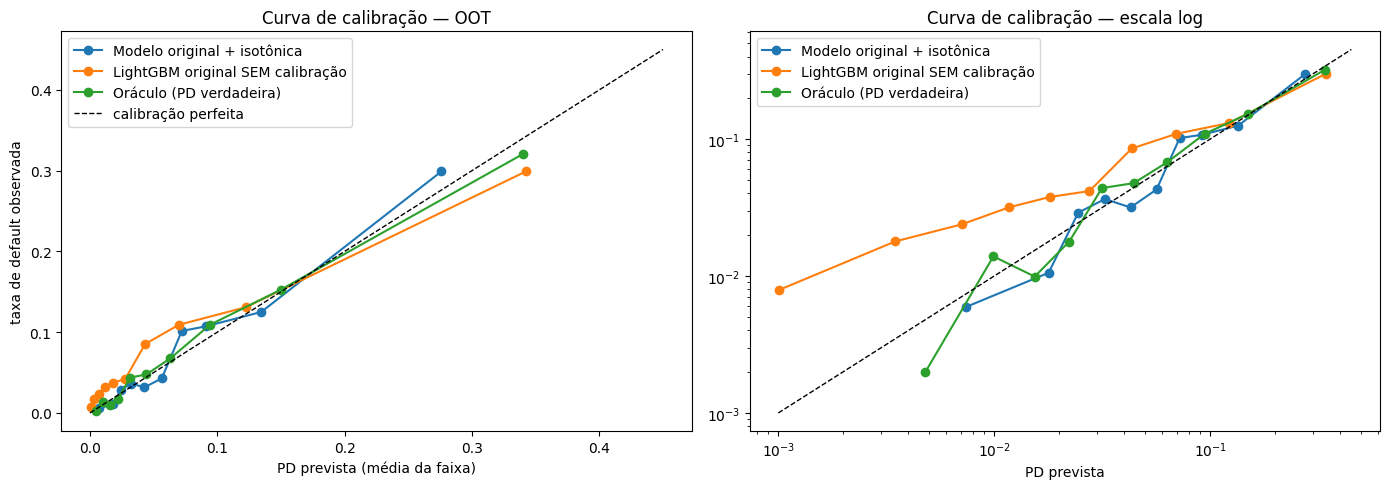

Calibration-in-the-large: PD média prevista 7.54% × taxa observada 7.85%


,clientes,pd_media,defaults,esperados,taxa_obs,p_valor_binomial
faixa,,,,,,
"(0.0, 0.02]",857,1.22%,8,10.5,0.93%,0.535
"(0.02, 0.05]",1651,3.26%,50,53.8,3.03%,0.677
"(0.05, 0.1]",1417,7.25%,116,102.7,8.19%,0.182
"(0.1, 0.2]",707,14.19%,101,100.3,14.29%,0.914
"(0.2, 1.0]",361,31.29%,121,112.9,33.52%,0.364


In [25]:
# ✅ Correção P11 — curva de calibração e teste binomial por faixa (modelo original, OOT).

# Curva de calibração com faixas por quantil (mesmo nº de clientes por ponto): no eixo x a
# PD média prevista da faixa, no y a taxa observada. Pontos sobre a diagonal = calibrado.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for nome, p in [("Modelo original + isotônica", pd_oot),
                ("LightGBM original SEM calibração", p_orig_raw.predict_proba(X_oot)[:, 1]),
                ("Oráculo (PD verdadeira)", oot["pd_real"].values)]:
    obs, prev_ = calibration_curve(y_oot, p, n_bins=10, strategy="quantile")
    ax[0].plot(prev_, obs, "o-", label=nome)
ax[0].plot([0, 0.45], [0, 0.45], "k--", lw=1, label="calibração perfeita")
ax[0].set_xlabel("PD prevista (média da faixa)"); ax[0].set_ylabel("taxa de default observada")
ax[0].set_title("Curva de calibração — OOT"); ax[0].legend()

# Mesma curva em escala log, onde se vê melhor o que acontece nas PDs baixas (onde está
# a maior parte da carteira e onde erros relativos grandes distorcem o preço).
for nome, p in [("Modelo original + isotônica", pd_oot),
                ("LightGBM original SEM calibração", p_orig_raw.predict_proba(X_oot)[:, 1]),
                ("Oráculo (PD verdadeira)", oot["pd_real"].values)]:
    obs, prev_ = calibration_curve(y_oot, p, n_bins=10, strategy="quantile")
    ax[1].loglog(prev_, obs, "o-", label=nome)
ax[1].plot([0.001, 0.45], [0.001, 0.45], "k--", lw=1)
ax[1].set_title("Curva de calibração — escala log"); ax[1].set_xlabel("PD prevista"); ax[1].legend()
plt.tight_layout(); plt.show()

# Teste binomial por faixa de PD: o nº de defaults observado é compatível com a PD média
# prevista? p-valor baixo (< 0,05) = a faixa está descalibrada além do que o acaso explica.
faixas_pd = pd.cut(pd_oot, [0, 0.02, 0.05, 0.10, 0.20, 1.0])
bt = pd.DataFrame({"y": y_oot.values, "p": pd_oot, "faixa": faixas_pd}).groupby("faixa", observed=True).agg(
    clientes=("y", "size"), pd_media=("p", "mean"), defaults=("y", "sum"))
bt["esperados"] = bt["pd_media"] * bt["clientes"]
bt["taxa_obs"] = bt["defaults"] / bt["clientes"]
bt["p_valor_binomial"] = [stats.binomtest(int(k), int(n), pm).pvalue for k, n, pm in zip(bt["defaults"], bt["clientes"], bt["pd_media"])]
print(f"Calibration-in-the-large: PD média prevista {pd_oot.mean():.2%} × taxa observada {y_oot.mean():.2%}")
bt.style.format({"pd_media": "{:.2%}", "esperados": "{:.1f}", "taxa_obs": "{:.2%}", "p_valor_binomial": "{:.3f}"})

**Leitura.** A curva do modelo calibrado fica perto da diagonal, e a do LightGBM **sem** calibração fica bem **acima** dela nas faixas baixas e médias: ele prevê PDs de 0,1% a 4% onde a taxa observada é de ~0,8% a ~8,5% — ou seja, **subestima** o risco da maior parte da carteira. É o efeito típico do overfitting: o modelo decorou o treino e empurra as probabilidades para os extremos (perto de zero para quem "parece" bom), com confiança que não se sustenta fora da amostra. É por isso que a escala logarítmica ajuda: nela, esse erro nas PDs baixas fica visível. Por faixa de PD, **nenhum teste binomial rejeita a calibração** (p-valores entre 0,18 e 0,91), e a PD média do OOT (7,5%) fica perto da taxa observada (7,9%). **Conclusão:** a calibração isotônica cumpriu o seu papel; o problema do modelo original é de **ordenação** (overfitting), não de nível. Na tabela de decis (seção 8), um decil isolado aparece fora do esperado (decil 7: PD 7,2% × bad rate 10,1%) — algo compatível com o acaso quando se testam 10 faixas ao mesmo tempo.

## 7. Threshold — por que 0,5 não serve para crédito

O notebook, corretamente, **não** usa 0,5 para decidir: ele procura um corte econômico (seção 9). Mas vale mostrar o porquê. Um threshold transforma a PD numa **decisão**: PD ≥ corte ⇒ reprovar. Mudar o corte move o equilíbrio entre:

- **Aprovação / rejeição** — volume de negócio.
- **Falsos positivos** (bons reprovados) — receita perdida, cliente perdido para a concorrência.
- **Falsos negativos** (maus aprovados) — perda de crédito.
- **Recall × precision** — quanto da perda evitamos × quantos bons sacrificamos para isso.
- **Exposição ao risco** — EAD dos maus que ficam na carteira.

O corte 0,5 do `predict()` do scikit-learn significa "reprove quem tem mais chance de dar default do que de pagar". Em crédito, reprovar só nesse caso aprova quase todo mundo, porque o **custo de um mau aprovado (perder ~65% da exposição) é muito maior que o ganho de um bom (a margem de um ano)**. O corte certo sai da economia: aprovar vale a pena enquanto `(1 − PD) × ganho > PD × perda`, ou seja, `PD < ganho / (ganho + perda)`.

In [26]:
# ✅ Complemento — o efeito do threshold sobre aprovação, erros e exposição (modelo original, OOT).

# Para cada corte: taxa de aprovação, falsos positivos (bons reprovados), falsos
# negativos (maus aprovados), recall, precision e a EAD dos maus que ficariam aprovados.
linhas_thr = []
for c in [0.05, 0.10, 0.15, 0.185, 0.30, 0.50]:
    reprova = pd_oot >= c
    y_ = y_oot.values
    linhas_thr.append({"corte": c, "aprovação": 1 - reprova.mean(),
                       "bons reprovados (FP)": int(((y_ == 0) & reprova).sum()),
                       "maus aprovados (FN)": int(((y_ == 1) & ~reprova).sum()),
                       "recall": ((y_ == 1) & reprova).sum() / (y_ == 1).sum(),
                       "precision": ((y_ == 1) & reprova).sum() / max(reprova.sum(), 1),
                       "EAD dos maus aprovados (R$ mi)": oot["ead"].values[(y_ == 1) & ~reprova].sum() / 1e6})
pd.DataFrame(linhas_thr).set_index("corte").style.format(
    {"aprovação": "{:.1%}", "recall": "{:.1%}", "precision": "{:.1%}", "EAD dos maus aprovados (R$ mi)": "{:.2f}"})

,aprovação,bons reprovados (FP),maus aprovados (FN),recall,precision,EAD dos maus aprovados (R$ mi)
corte,,,,,,
0.050000,50.7%,2147,58,85.4%,13.6%,0.23
0.100000,78.8%,846,174,56.1%,20.8%,0.88
0.150000,87.5%,464,229,42.2%,26.5%,1.25
0.185000,91.6%,291,261,34.1%,31.7%,1.48
0.300000,96.9%,96,335,15.4%,38.9%,1.98
0.500000,99.4%,14,379,4.3%,54.8%,2.29


**Leitura.** Com corte 0,5, praticamente todos são aprovados e quase toda a exposição dos maus entra na carteira. Descendo o corte, o recall sobe e a EAD dos maus aprovados cai, mas o número de bons reprovados cresce rapidamente. **Não existe corte "estatisticamente certo"**: o corte ótimo depende da margem, da LGD, do custo operacional e da estratégia comercial — por isso ele é uma decisão de negócio, calculada na seção 9 (e escolhida na validação, não no teste).

## 8. Expected Loss e P&L por cliente

$$\text{Expected Loss} = PD \times LGD \times EAD$$

- **PD (Probability of Default):** probabilidade de o cliente entrar em default no horizonte (12 meses). Vem do modelo — e precisa estar **calibrada**.
- **LGD (Loss Given Default):** fração da exposição que **não é recuperada** depois do default (cobrança, garantias, acordos). LGD de 65% = recupera 35 centavos de cada real.
- **EAD (Exposure at Default):** quanto o cliente deve no momento do default.
- **EL:** perda **média** esperada; é custo do negócio (entra no preço e na provisão). Perdas **acima** da média (perda inesperada) são cobertas por capital.

> 🟢 **Correto:** o notebook conecta a PD com LGD e EAD, e o lucro ajustado ao risco pondera a receita pela probabilidade de sobrevivência (1 − PD). É exatamente o raciocínio de precificação ajustada ao risco (RAROC simplificado).

In [27]:
# [ORIGINAL — célula 6]

# LGD por perfil: parte de 55% e sobe com a utilização e com os atrasos, até 92%.
# É uma REGRA ASSUMIDA, não estimada: numa instituição real, a LGD vem de um modelo
# próprio, ajustado nas recuperações observadas de defaults passados (workout LGD).
# A intuição é razoável: quem usa mais o limite e já atrasou tende a ter menos a
# recuperar (ver P12).
def lgd_por_perfil(frame, base=0.55, teto=0.92):
    """LGD cresce com utilização de limite e histórico de atraso."""
    # Ajuste linear da LGD pelo perfil de risco.
    ajuste = 0.22*frame["utilizacao_limite"] + 0.012*frame["atrasos_12m"]
    # Limita a LGD entre a base e o teto (uma LGD não pode passar de 100%).
    return (base + ajuste).clip(base, teto)

# Margem financeira anual sobre a exposição (receita de juros líquida de captação, por
# hipótese). É a premissa que mais move o corte ótimo — deve vir da área de Finanças.
# receita anual sobre a exposição
MARGEM_FINANCEIRA = 0.19
# Custo operacional fixo por cliente por ano (servir, cobrar, atender).
# custo por cliente/ano
CUSTO_OPERACIONAL = 180

# Monta o P&L esperado de cada cliente a partir da PD prevista.
def montar_pl(frame, pd_hat, margem=MARGEM_FINANCEIRA, custo_op=CUSTO_OPERACIONAL):
    # Cópia para não alterar a base de entrada.
    out = frame.copy()
    # PD prevista pelo modelo e LGD pela regra de perfil.
    out["pd"]  = pd_hat
    out["lgd"] = lgd_por_perfil(frame)

    # Perda esperada
    # EL = PD × LGD × EAD, cliente a cliente.
    out["expected_loss"] = out["pd"] * out["lgd"] * out["ead"]

    # Receita: quem dá default não paga o ano inteiro -> pondera por (1 - PD)
    # Receita esperada = margem × EAD × probabilidade de o cliente continuar pagando.
    out["receita_esperada"] = out["ead"] * margem * (1 - out["pd"])
    # Custo operacional fixo por cliente.
    out["custo_op"] = custo_op

    # Lucro ajustado ao risco = receita esperada − perda esperada − custo. Note que é um
    # valor ESPERADO, calculado com a PD do modelo — não é o lucro que aconteceu (P13).
    out["lucro_ajustado"] = (out["receita_esperada"]
                             - out["expected_loss"]
                             - out["custo_op"])
    return out

# Carteira do OOT com o P&L esperado de cada cliente.
carteira = montar_pl(oot, pd_oot)

# Estatísticas descritivas dos componentes do P&L.
carteira[["pd","lgd","ead","expected_loss","receita_esperada","lucro_ajustado"]].describe().round(2)

,pd,lgd,ead,expected_loss,receita_esperada,lucro_ajustado
count,"5,042.000","5,042.000","5,042.000","5,042.000","5,042.000","5,042.000"
mean,0.080,0.650,"4,734.040",302.690,816.510,333.820
std,0.080,0.050,"4,638.940",589.790,798.760,745.300
min,0.000,0.550,300.000,0.000,37.940,"-6,530.580"
25%,0.020,0.610,"1,746.160",33.180,314.750,10.570
50%,0.050,0.640,"3,395.340",109.290,591.850,203.340
75%,0.090,0.680,"6,102.450",311.200,"1,041.940",528.340
max,0.740,0.780,"52,662.100","8,149.670","9,567.260","7,725.500"


### 🔴 P12 — LGD e margem são premissas não estimadas, e o P&L ignora custo de capital

- **Problema:** a LGD é uma regra linear escolhida à mão; a margem (19%) e o custo (R$ 180) são constantes; a EAD é o saldo atual (P4); o P&L não inclui **custo de capital** nem valor do dinheiro no tempo.
- **Por que é um problema:** o corte ótimo e o "ganho da política" são **tão bons quanto essas premissas**. Uma LGD 10 pontos maior muda o ponto de equilíbrio de todos os clientes.
- **Impacto:** a política pode estar aprovando clientes cujo retorno não remunera o capital alocado.
- **Correção:** estimar LGD com dados de recuperação (ou usar parâmetros regulatórios/corporativos documentados), estimar CCF, incluir custo de capital (capital econômico × custo do capital próprio) e fazer **análise de sensibilidade** do corte às premissas.

In [28]:
# [ORIGINAL — célula 7]

# Decis de risco: divide a carteira em 10 grupos de mesmo tamanho pela PD. O +1 faz os
# decis irem de 1 (menor risco) a 10 (maior risco). duplicates="drop" é necessário
# porque a calibração isotônica gera PDs empatadas — por isso os decis não têm
# exatamente 10% dos clientes cada.
carteira["decil_risco"] = pd.qcut(carteira["pd"], 10, labels=False, duplicates="drop") + 1

# Tabela por decil: é ao mesmo tempo um teste de ORDENAÇÃO (a bad rate real deve
# crescer do decil 1 ao 10) e de CALIBRAÇÃO (pd_media deve ficar perto de bad_rate_real).
resumo = (carteira.groupby("decil_risco")
          .agg(clientes=("pd","size"),
               pd_media=("pd","mean"),
               bad_rate_real=("default","mean"),
               ead_total=("ead","sum"),
               perda_esperada=("expected_loss","sum"),
               lucro_ajustado=("lucro_ajustado","sum"))
          .round(3))

# Lucro médio por cliente em cada decil: mostra onde a carteira gera e destrói valor.
resumo["lucro_por_cliente"] = (resumo["lucro_ajustado"]/resumo["clientes"]).round(2)
resumo

,clientes,pd_media,bad_rate_real,ead_total,perda_esperada,lucro_ajustado,lucro_por_cliente
decil_risco,,,,,,,
1,506,0.007,0.006,"1,555,633.830","8,093.030","193,954.820",383.310
2,569,0.018,0.011,"1,908,940.190","21,957.676","231,783.144",407.350
3,448,0.024,0.029,"1,723,958.490","27,239.637","211,646.677",472.430
4,494,0.033,0.036,"2,050,067.470","43,447.334","244,458.579",494.860
5,506,0.043,0.032,"2,380,583.210","66,702.810","275,278.822",544.030
6,514,0.056,0.043,"2,517,144.500","95,352.815","263,270.200",512.200
7,493,0.072,0.101,"2,455,674.270","119,580.416","224,495.048",455.370
8,503,0.091,0.107,"2,657,540.330","164,332.722","204,088.352",405.740
9,504,0.135,0.125,"3,204,912.490","298,441.419","137,997.294",273.800


**Leitura.** A ordenação é boa (bad rate de ~0,6% no decil 1 a ~30% no decil 10) e a calibração por decil é razoável, mas **não monotônica** nos decis do meio (decil 5 com bad rate menor que o 4; decil 7 com PD média de 7,2% e bad rate de 10,1%). Parte disso é ruído (~500 clientes por decil ⇒ IC de ±2–3 pontos), parte é a instabilidade do modelo sobreajustado. Só o **decil 10 destrói valor** em lucro esperado — a política ótima deve cortar uma parte dele.

## 9. Política de crédito — o corte ótimo de PD

In [29]:
# [ORIGINAL — célula 8]

# Curva de política: para cada corte de PD, simula "aprovar quem tem PD ≤ corte" e mede
# aprovação, bad rate dos aprovados, perda esperada e lucro. É a ferramenta certa para
# escolher o corte — o problema está em ONDE ela é calculada e COM QUAL lucro (P13).
def curva_politica(tabela, grid=None):
    # Grade de cortes de 1% a 60% em passos de 0,5 ponto percentual.
    grid = np.arange(0.01, 0.61, 0.005) if grid is None else grid
    linhas = []
    for c in grid:
        # Aprovados neste corte.
        ap = tabela[tabela["pd"] <= c]
        # Sem aprovados não há o que medir.
        if len(ap) == 0:
            continue
        # Métricas da carteira aprovada. A bad rate usa o default REAL, mas o lucro usa
        # o lucro ESPERADO (calculado com a própria PD do modelo).
        linhas.append({
            "corte_pd": round(float(c), 4),
            "taxa_aprovacao": len(ap)/len(tabela),
            "bad_rate_aprovados": ap["default"].mean(),
            "perda_esperada": ap["expected_loss"].sum(),
            "lucro_total": ap["lucro_ajustado"].sum(),
        })
    return pd.DataFrame(linhas)

# Curva calculada NO OOT e corte escolhido NO OOT (P5 / P13).
curva = curva_politica(carteira)
melhor = curva.loc[curva["lucro_total"].idxmax()]

# Referência: lucro esperado se todos fossem aprovados.
lucro_sem_politica = carteira["lucro_ajustado"].sum()
ganho = melhor["lucro_total"] - lucro_sem_politica

# Relatório: corte, aprovação, bad rate e ganho da política.
print(f"Corte ótimo de PD        : {melhor['corte_pd']:.3f}")
print(f"Taxa de aprovação        : {melhor['taxa_aprovacao']:.1%}")
print(f"Bad rate dos aprovados   : {melhor['bad_rate_aprovados']:.2%}")
print(f"Lucro com política       : R$ {melhor['lucro_total']:,.2f}")
print(f"Lucro aprovando todos    : R$ {lucro_sem_politica:,.2f}")
print(f"Ganho da política        : R$ {ganho:,.2f}  ({ganho/abs(lucro_sem_politica):.1%})")

Corte ótimo de PD        : 0.185
Taxa de aprovação        : 91.6%
Bad rate dos aprovados   : 5.65%
Lucro com política       : R$ 1,989,825.19
Lucro aprovando todos    : R$ 1,683,141.85
Ganho da política        : R$ 306,683.34  (18.2%)


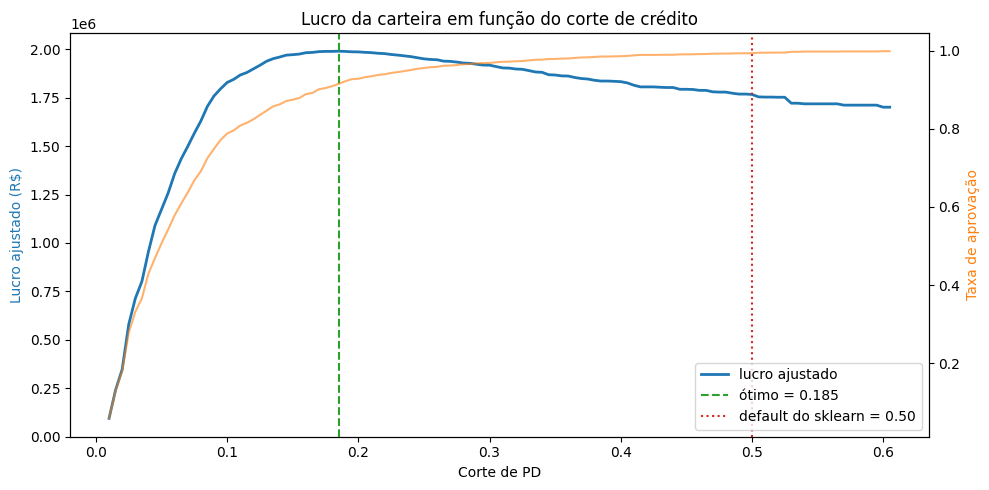

In [30]:
# [ORIGINAL — célula 9]

# Gráfico da curva de lucro (eixo esquerdo) e da taxa de aprovação (eixo direito).
fig, ax1 = plt.subplots(figsize=(10, 5))

# Lucro por corte, o corte ótimo (verde) e o threshold padrão do sklearn (vermelho):
# contraste didático entre "decisão econômica" e "0,5 por padrão".
ax1.plot(curva["corte_pd"], curva["lucro_total"], lw=2, color="tab:blue", label="lucro ajustado")
ax1.axvline(melhor["corte_pd"], color="tab:green", ls="--", label=f"ótimo = {melhor['corte_pd']:.3f}")
ax1.axvline(0.50, color="tab:red", ls=":", label="default do sklearn = 0.50")
ax1.set_xlabel("Corte de PD"); ax1.set_ylabel("Lucro ajustado (R$)", color="tab:blue")

# Segundo eixo com a taxa de aprovação: mostra o custo comercial de cada corte.
ax2 = ax1.twinx()
ax2.plot(curva["corte_pd"], curva["taxa_aprovacao"], color="tab:orange", alpha=.6, label="aprovação")
ax2.set_ylabel("Taxa de aprovação", color="tab:orange")

# Título, legenda e exibição.
ax1.set_title("Lucro da carteira em função do corte de crédito")
ax1.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 🔴 P13 — O corte é escolhido no OOT e o "lucro" é o lucro que o próprio modelo prevê

- **Problema:** (a) a curva e o corte ótimo são calculados **no conjunto de teste** (P5); (b) o `lucro_total` soma o `lucro_ajustado`, que é calculado **com a PD prevista** — não com o default que de fato aconteceu. O modelo **avalia a si mesmo**: se ele superestimasse o risco, o lucro "esperado" também sairia distorcido, e a curva não mostraria nada.
- **Por que é um problema:** o número reportado ("Lucro com política R$ 1,99 mi") não é um resultado observado, é uma **previsão**; e ele é otimizado e medido na mesma amostra.
- **Impacto (medido abaixo):** aprovando todos, o lucro esperado era R$ 1,68 mi, mas o lucro **realizado** (com os defaults que aconteceram) é R$ 1,49 mi. O corte escolhido na validação, aplicado ao OOT, dá um resultado honesto do ganho.
- **Correção:** (i) calcular o lucro **realizado** — bom pagador gera `margem × EAD − custo`; mau pagador gera `−LGD × EAD − custo`; (ii) escolher o corte na **validação** e reportar o ganho no **OOT**; (iii) comparar com a regra de **ponto de equilíbrio individual**: aprovar quem tem lucro esperado positivo, que usa a PD, a LGD e a EAD de cada cliente em vez de um corte único.

In [31]:
# ✅ Correção P13 — lucro REALIZADO, corte escolhido na VALIDAÇÃO, resultado medido no OOT.

# Lucro realizado de cada cliente: usa o default observado, e não a PD prevista.
def lucro_realizado(frame):
    lgd = lgd_por_perfil(frame)
    return np.where(frame["default"] == 1,
                    -lgd * frame["ead"] - CUSTO_OPERACIONAL,
                    frame["ead"] * MARGEM_FINANCEIRA - CUSTO_OPERACIONAL)

# Curva de lucro realizado para uma PD qualquer, num grid de cortes.
GRID = np.round(np.arange(0.01, 0.61, 0.005), 4)
def curva_realizada(frame, pd_hat):
    lr_ = lucro_realizado(frame)
    return pd.Series({c: lr_[pd_hat <= c].sum() for c in GRID})

# 1) Escolha do corte na VALIDAÇÃO, com o procedimento original re-treinado só em
#    jan–jun (a PD de jul–set vem de um modelo que não viu jul–set).
p_val_orig = P_VAL["LightGBM original + isotônica (procedimento do notebook)"]
corte_val = curva_realizada(val_dev, p_val_orig).idxmax()

# 2) Aplicação ao OOT (modelo original do notebook, treinado em jan–set).
lucro_real_oot = lucro_realizado(oot)
res13 = pd.DataFrame({
    "Aprovar todos": {"corte": np.nan, "aprovação": 1.0, "lucro esperado (R$ mi)": carteira["lucro_ajustado"].sum() / 1e6,
                      "lucro REALIZADO (R$ mi)": lucro_real_oot.sum() / 1e6},
    "Corte escolhido NO OOT (original)": {"corte": melhor["corte_pd"], "aprovação": (pd_oot <= melhor["corte_pd"]).mean(),
                      "lucro esperado (R$ mi)": melhor["lucro_total"] / 1e6,
                      "lucro REALIZADO (R$ mi)": lucro_real_oot[pd_oot <= melhor["corte_pd"]].sum() / 1e6},
    "Corte escolhido na VALIDAÇÃO": {"corte": corte_val, "aprovação": (pd_oot <= corte_val).mean(),
                      "lucro esperado (R$ mi)": carteira.loc[pd_oot <= corte_val, "lucro_ajustado"].sum() / 1e6,
                      "lucro REALIZADO (R$ mi)": lucro_real_oot[pd_oot <= corte_val].sum() / 1e6},
    "Equilíbrio individual (lucro esperado > 0)": {"corte": np.nan, "aprovação": (carteira["lucro_ajustado"] > 0).mean(),
                      "lucro esperado (R$ mi)": carteira.loc[carteira["lucro_ajustado"] > 0, "lucro_ajustado"].sum() / 1e6,
                      "lucro REALIZADO (R$ mi)": lucro_real_oot[carteira["lucro_ajustado"].values > 0].sum() / 1e6},
}).T
res13["ganho realizado vs. aprovar todos (R$ mi)"] = res13["lucro REALIZADO (R$ mi)"] - res13.loc["Aprovar todos", "lucro REALIZADO (R$ mi)"]
res13.style.format({"corte": "{:.3f}", "aprovação": "{:.1%}", "lucro esperado (R$ mi)": "{:.3f}",
                    "lucro REALIZADO (R$ mi)": "{:.3f}", "ganho realizado vs. aprovar todos (R$ mi)": "{:+.3f}"}, na_rep="—")

,corte,aprovação,lucro esperado (R$ mi),lucro REALIZADO (R$ mi),ganho realizado vs. aprovar todos (R$ mi)
Aprovar todos,—,100.0%,1.683,1.491,+0.000
Corte escolhido NO OOT (original),0.185,91.6%,1.990,1.862,+0.370
Corte escolhido na VALIDAÇÃO,0.195,92.7%,1.987,1.842,+0.351
Equilíbrio individual (lucro esperado > 0),—,76.7%,2.041,1.905,+0.414


**Leitura.**
- O lucro **esperado** (calculado com a PD do modelo) é sistematicamente **maior** que o **realizado**. A diferença vem de a PD média prevista (7,5%) ficar abaixo da taxa observada (7,9%) e dos desvios de calibração por faixa: o modelo "promete" mais do que entrega.
- Com o corte escolhido **na validação**, o resultado realizado no OOT é o número honesto para levar a um comitê. Aqui ele fica próximo do corte escolhido no próprio OOT porque a curva de lucro é **achatada** perto do ótimo — mas isso só se sabe depois de medir.
- A regra de **equilíbrio individual** (aprovar quem tem lucro esperado > 0) aprova menos gente e gera **mais** lucro realizado que qualquer corte único de PD: um cliente com EAD alta e LGD baixa aguenta uma PD maior do que um cliente com EAD baixa, cujo lucro não cobre o custo fixo. A PD calibrada permite decidir **cliente a cliente**.

In [32]:
# [ORIGINAL — célula 10]

# Política em faixas (A–E) com cortes fixos de PD: traduz a PD em ações de negócio
# (limite ampliado, padrão, reduzido, análise manual, recusa). Os cortes são
# ARBITRÁRIOS (não saem da curva de lucro) — ver P14.
def politica_faixas(pd_valor):
    if pd_valor <= 0.03:  return "A - aprovar com limite ampliado"
    if pd_valor <= 0.08:  return "B - aprovar limite padrão"
    if pd_valor <= 0.15:  return "C - aprovar limite reduzido"
    if pd_valor <= 0.30:  return "D - análise manual / garantia"
    return "E - recusar"

# Aplica a regra cliente a cliente (apply linha a linha; para milhões de clientes,
# pd.cut seria a versão vetorizada).
carteira["faixa"] = carteira["pd"].apply(politica_faixas)

# Painel por faixa: volume, PD média × bad rate (calibração por faixa), exposição e lucro.
# sort_index funciona porque os rótulos começam com A, B, C, D, E.
painel = (carteira.groupby("faixa")
          .agg(clientes=("pd","size"),
               pd_media=("pd","mean"),
               bad_rate=("default","mean"),
               ead_total=("ead","sum"),
               lucro_ajustado=("lucro_ajustado","sum"))
          .sort_index()
          .round(3))

# Participação de cada faixa na carteira.
painel["% carteira"] = (painel["clientes"]/painel["clientes"].sum()*100).round(1)
painel

,clientes,pd_media,bad_rate,ead_total,lucro_ajustado,% carteira
faixa,,,,,,
A - aprovar com limite ampliado,1672,0.017,0.016,"5,809,347.010","713,493.088",33.200
B - aprovar limite padrão,1816,0.052,0.054,"8,591,657.570","916,215.849",36.000
C - aprovar limite reduzido,923,0.105,0.114,"5,272,828.790","342,166.099",18.300
D - análise manual / garantia,474,0.201,0.224,"3,095,044.330","-54,155.803",9.400
E - recusar,157,0.409,0.389,"1,100,139.770","-234,577.380",3.100


### 🔴 P14 — Faixas de política arbitrárias e inconsistentes com o corte ótimo

- **Problema:** os limites das faixas (3%, 8%, 15%, 30%) não vêm de nenhuma análise, e a política de faixas **contradiz** a curva de lucro: a curva diz "aprove até PD 18,5%", mas as faixas mandam para análise manual a partir de 15%. Além disso, a faixa A ("limite **ampliado**") calcula o lucro com a EAD **atual**, ignorando que a própria decisão aumenta a exposição (P4).
- **Por que é um problema:** duas políticas diferentes no mesmo notebook, sem critério para escolher; e a decisão de limite afeta a EAD, que afeta a perda — o efeito da decisão não está no P&L.
- **Impacto:** a faixa D tem lucro esperado **negativo** e a E destrói ~R$ 235 mil — mas parte da faixa D (PD entre 15% e 18,5%) seria aprovada pela curva.
- **Correção:** derivar as faixas de uma **master scale** (faixas de rating com PD crescente e taxas observadas monotônicas e dentro do IC), definir as ações com a área de negócio a partir do **lucro por faixa** e, para decisões de limite, simular o P&L **com o novo limite** (EAD nova).

> 🟢 **Correto:** as faixas são **monotônicas** e bem calibradas no agregado (PD média ≈ bad rate em todas), o que confirma que a PD calibrada pode ser usada para segmentar a carteira.

## 10. Estabilidade e stress test — PSI sob choque macroeconômico

**PSI (Population Stability Index)** mede o quanto a distribuição de uma variável (ou do score) mudou entre uma população de **referência** e uma população **atual**: divide a referência em faixas (decis), compara o % de clientes em cada faixa e soma $(\%_{atual} - \%_{ref}) \cdot \ln(\%_{atual}/\%_{ref})$. Régua de mercado: < 0,10 estável; 0,10–0,25 atenção; > 0,25 mudança relevante.

O notebook simula safras com um **choque macro** (mais utilização, mais atrasos, renda menor) e mede o PSI do score. A ideia é ótima — é o teste de estresse que todo modelo deveria ter. Há quatro problemas de desenho, detalhados em P15.

In [33]:
# [ORIGINAL — célula 11]

# PSI entre uma distribuição de referência ("esperado") e uma atual ("observado").
def psi(esperado, observado, bins=10):
    # Faixas definidas pelos decis da REFERÊNCIA; extremos abertos para capturar valores
    # novos fora da faixa original.
    cortes = np.quantile(esperado, np.linspace(0, 1, bins+1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    # Proporção de clientes em cada faixa, na referência e na população atual.
    e = np.histogram(esperado, bins=cortes)[0] / len(esperado)
    o = np.histogram(observado, bins=cortes)[0] / len(observado)
    # Piso de 1e-6 para evitar log(0) em faixas vazias.
    e, o = np.clip(e, 1e-6, None), np.clip(o, 1e-6, None)
    # Soma dos termos do PSI.
    return float(np.sum((o - e) * np.log(o/e)))


# Gera uma safra nova e aplica um choque macro de intensidade "choque".
def safra_com_choque(n=8000, seed=7, choque=1.0):
    """Choque macro: mais uso de limite, mais atrasos, renda real menor."""
    # Base nova com outra semente (outros clientes, mesmo mecanismo). Atenção: o
    # default desta base é sorteado ANTES do choque, então ele não reflete o choque.
    nova = gerar_base(n=n, seed=seed)
    # Utilização +12 p.p. × choque (limitada a 100%). A EAD NÃO é atualizada, embora no
    # gerador ela seja limite × utilização — inconsistência do cenário.
    nova["utilizacao_limite"] = (nova["utilizacao_limite"] + 0.12*choque).clip(0, 1)
    # Mais atrasos (atraso_max_dias não é atualizado — outra inconsistência).
    nova["atrasos_12m"]       = (nova["atrasos_12m"] + np.round(1.2*choque)).clip(0, 12)
    # Renda real menor.
    nova["renda_mensal"]      = nova["renda_mensal"] * (1 - 0.10*choque)
    # DTI recalculado com a renda nova. Efeito colateral: para quem tem renda ausente, o
    # DTI agora vira NaN (no gerador ele existia), e o pipeline o imputa pela mediana.
    nova["dti"] = (nova["ead"] / (nova["renda_mensal"]*12)).clip(0, 3)
    return nova


# Para cada intensidade de choque: PSI do score, PD média e perda esperada total.
linhas = []
for choque in [0.0, 0.5, 1.0, 1.5]:
    nova = safra_com_choque(choque=choque)
    pd_nova = modelo.predict_proba(nova[FEATURES])[:, 1]
    # A referência do PSI é o score do OOT. O padrão de mercado é usar a população de
    # DESENVOLVIMENTO (treino) como referência fixa.
    valor_psi = psi(pd_oot, pd_nova)
    # Classificação pela régua de mercado. "RECALIBRAR" é uma conclusão forte demais para
    # o PSI sozinho: ele mede mudança na POPULAÇÃO, não erro do modelo (P15).
    status = ("estável" if valor_psi < 0.10
              else "atenção" if valor_psi < 0.25
              else "RECALIBRAR")
    linhas.append({
        "choque_macro": choque,
        "psi": round(valor_psi, 4),
        "pd_media": round(pd_nova.mean(), 4),
        "el_total": round((pd_nova * lgd_por_perfil(nova) * nova["ead"]).sum(), 2),
        "status": status,
    })

# Tabela do stress test: PSI, PD média e perda esperada por intensidade de choque.
pd.DataFrame(linhas)

,choque_macro,psi,pd_media,el_total,status
0,0.000,0.003,0.076,"2,385,005.810",estável
1,0.500,0.123,0.105,"3,379,282.520",atenção
2,1.000,0.232,0.117,"3,789,329.090",atenção
3,1.500,0.791,0.162,"5,270,777.320",RECALIBRAR


### 🔴 P15 — O stress test mede a mudança da população, mas não se o modelo continua certo

- **Problema:** (a) o default das safras "com choque" é sorteado **antes** do choque, então não dá para medir se a PD prevista acompanha o risco verdadeiro; (b) o status "RECALIBRAR" é deduzido **só do PSI**; (c) a referência do PSI é o próprio OOT, sem ser documentada como a referência oficial do modelo; (d) o cenário é internamente inconsistente (a utilização sobe, mas a EAD não; os atrasos sobem, mas o atraso máximo não; o DTI vira missing para quem não tem renda).
- **Por que é um problema:** o PSI mede **data drift** (mudou quem chega), não **erro do modelo**. Se o choque só muda o perfil (covariate shift) e a relação entre variáveis e default continua a mesma, um modelo bem especificado **continua calibrado** — a PD sobe porque os clientes ficaram mais arriscados, e isso é o comportamento **correto**. Recalibrar nesse caso **pioraria** o modelo. Já uma mudança na relação (concept drift) pode acontecer com PSI verde.
- **Impacto:** decisões de monitoramento erradas nas duas direções: recalibrar sem necessidade, ou não perceber um modelo errado.
- **Correção:** fixar e documentar a distribuição de referência no momento da aprovação do modelo (scores **fora da amostra** do desenvolvimento — para um modelo sobreajustado, os scores do próprio treino são distorcidos e não servem de referência); aplicar o choque de forma **consistente**; e, como aqui conhecemos o mecanismo verdadeiro, calcular a **PD verdadeira sob choque** e comparar com a PD prevista (célula abaixo). Em produção, isso corresponde a acompanhar a **taxa de default realizada por safra** contra a PD prevista (backtesting) — só a performance observada detecta erro do modelo.

In [34]:
# ✅ Correção P15 — PD VERDADEIRA sob choque × PD prevista.

# Reprodução EXATA do mecanismo causal da função gerar_base (mesmos coeficientes).
# Só é possível porque os dados são sintéticos: com dados reais, o equivalente é a
# taxa de default observada quando a safra amadurecer.
def pd_verdadeira(f):
    logit_v = (-3.55 + 3.60 * f["utilizacao_limite"] + 0.42 * f["atrasos_12m"] + 0.016 * f["atraso_max_dias"]
               + 1.90 * f["dti"] + 0.30 * f["consultas_bureau_6m"] - 0.030 * (f["idade"] - 20)
               - 0.016 * f["tempo_casa_meses"] - 0.14 * f["n_produtos"] - 0.70 * (f["renda_mensal"] > 9000)
               + 0.45 * (f["canal_aquisicao"] == "PARCEIRO"))
    return 1 / (1 + np.exp(-logit_v))

# Modelos que vamos estressar: o original e a logística (ambos treinados em jan–set).
logit_full = pipeline_logistica().fit(X_tr, y_tr)
linhas_st = []
for choque in [0.0, 0.5, 1.0, 1.5]:
    # Mesmo cenário do original; a PD verdadeira é calculada só onde a renda existe
    # (sem a renda verdadeira não há como reproduzir o mecanismo).
    nova_c = safra_com_choque(choque=choque)
    ok = nova_c["renda_mensal"].notna().values
    pv = pd_verdadeira(nova_c).values[ok]
    p_o = modelo.predict_proba(nova_c[FEATURES])[:, 1][ok]
    p_l = logit_full.predict_proba(nova_c[FEATURES])[:, 1][ok]
    linhas_st.append({"choque": choque,
                      "PSI (original, como no notebook)": psi(pd_oot, modelo.predict_proba(nova_c[FEATURES])[:, 1]),
                      "PD verdadeira média": pv.mean(),
                      "PD prevista — original": p_o.mean(),
                      "PD prevista — logística": p_l.mean(),
                      "correlação com a PD verdadeira — original": np.corrcoef(p_o, pv)[0, 1],
                      "correlação com a PD verdadeira — logística": np.corrcoef(p_l, pv)[0, 1]})
pd.DataFrame(linhas_st).set_index("choque").style.format("{:.4f}")

,"PSI (original, como no notebook)",PD verdadeira média,PD prevista — original,PD prevista — logística,correlação com a PD verdadeira — original,correlação com a PD verdadeira — logística
choque,,,,,,
0.000000,0.0029,0.0790,0.0761,0.0767,0.8906,0.9924
0.500000,0.1234,0.1276,0.1054,0.1250,0.8875,0.9927
1.000000,0.2324,0.1494,0.1178,0.1437,0.8864,0.9926
1.500000,0.7910,0.2252,0.1623,0.2191,0.8756,0.9925


**Leitura.**
- O **PSI** cresce com o choque, como esperado: a população mudou.
- A **PD verdadeira** sobe muito mais que a PD prevista pelo modelo original: sob choque forte, o LightGBM **subestima** o risco. Árvores não extrapolam — para valores de utilização e atrasos acima do que viram no treino, a previsão fica "presa" no valor da última folha.
- A **logística** acompanha a PD verdadeira de perto, porque o mecanismo é linear no log-odds e a extrapolação linear está, neste mundo, correta. Em dados reais nenhum modelo extrapola com garantia — por isso o stress test deve comparar a PD prevista com **cenários de PD construídos por especialistas** ou com safras de crises passadas.
- **Conclusão para o monitoramento:** PSI alto é um **alarme para investigar**, não uma ordem para recalibrar. A decisão de recalibrar vem do **backtesting** (PD prevista × default realizado).

## 11. CLV ajustado ao risco

In [35]:
# [ORIGINAL — célula 12]

# Horizonte de 3 anos e taxa de desconto de 10% a.a. para trazer fluxos futuros a
# valor presente.
HORIZONTE_ANOS = 3
TAXA_DESCONTO  = 0.10

# CLV simplificado: margem anual descontada, ponderada por sobrevivência ao default
# Fluxo anual = margem sobre a EAD − custo operacional (supõe EAD constante nos 3 anos).
fluxo_anual = carteira["ead"] * MARGEM_FINANCEIRA - CUSTO_OPERACIONAL
# Fator de valor presente com sobrevivência: soma de (1−PD)^t / (1+i)^t. Supõe que a PD
# de 12 meses se repete todo ano (hazard constante) — simplificação forte, porque a PD
# de clientes que sobrevivem tende a cair (e a de clientes em deterioração, a subir).
fatores = sum(((1 - carteira["pd"])**t) / ((1 + TAXA_DESCONTO)**t)
              for t in range(1, HORIZONTE_ANOS + 1))

# CLV = fluxo anual × fator de sobrevivência descontado.
carteira["clv"]  = fluxo_anual * fatores
# Perda no horizonte = EL anual × 3 × 0,7. O 0,7 ("perda decai") é um número mágico sem
# justificativa, e a perda não é descontada nem ponderada pela sobrevivência (P16).
# perda decai
carteira["el_horizonte"] = carteira["expected_loss"] * HORIZONTE_ANOS * 0.7
# CLV ajustado ao risco = CLV − perda no horizonte.
carteira["rclv"] = carteira["clv"] - carteira["el_horizonte"]

# Segmentação 2×2 pela mediana de CLV e de PD: separa clientes "valiosos e seguros" de
# "pouco valiosos e arriscados" para ação comercial diferenciada.
carteira["seg_valor"] = np.where(carteira["clv"] >= carteira["clv"].median(), "CLV alto", "CLV baixo")
carteira["seg_risco"] = np.where(carteira["pd"] <= carteira["pd"].median(), "risco baixo", "risco alto")

# RCLV médio e número de clientes em cada quadrante.
matriz = (carteira.pivot_table(index="seg_valor", columns="seg_risco",
                               values="rclv", aggfunc=["mean","count"])
          .round(2))
matriz

mean                  count            
seg_risco risco alto risco baixo risco alto risco baixo
seg_valor                                              
CLV alto   1,004.420   2,530.040       1505        1016
CLV baixo    -72.640     209.580       1014        1507

### 🔴 P16 — CLV com premissas ad hoc

- **Problema:** EAD constante por 3 anos; PD de 12 meses repetida como taxa anual constante; perda no horizonte = EL × 3 × 0,7 (fator sem justificativa, sem desconto e sem sobrevivência).
- **Por que é um problema:** a receita é descontada e ponderada pela sobrevivência, mas a perda não: as duas pernas do CLV usam lógicas diferentes. E a PD de 12 meses não é uma PD *lifetime*.
- **Impacto:** o CLV favorece clientes de EAD alta e risco moderado de forma pouco controlada; a segmentação 2×2 herda essas distorções.
- **Correção:** tratar receita e perda com a mesma estrutura: para cada ano t, $\text{sobrevivência}_{t-1} \times [(1-PD_t)\cdot \text{margem} - PD_t \cdot LGD \cdot EAD_t] / (1+i)^t$, com $PD_t$ vinda de uma **curva de PD lifetime** (como a exigida pelo IFRS 9 / CMN 4.966 para estágio 2) e $EAD_t$ seguindo a amortização ou o uso esperado do limite.

## 12. Interpretabilidade — o que o modelo aprendeu

Quatro coisas diferentes costumam ser confundidas:

| Conceito | Pergunta que responde | Ferramenta |
|---|---|---|
| **Correlação** | As duas variáveis andam juntas (linearmente)? | Pearson/Spearman |
| **Associação** | O default é diferente entre grupos da variável? | Bad rate por faixa, qui-quadrado |
| **Importância preditiva** | Quanto o **modelo** depende da variável para prever? | Permutação, SHAP, ganho |
| **Causalidade** | Se eu **mudar** a variável, o risco muda? | Experimento (A/B), inferência causal |

Importância alta **não** significa que a variável causa o default, nem que intervir nela mudaria o risco. Em crédito isso importa muito: "consultas ao bureau são importantes" não autoriza a conclusão de que reduzir consultas reduziria o default. Nenhuma célula deste notebook tem desenho causal; todas as leituras são de **associação** ou de **importância preditiva**.

Correlação PD prevista x PD real: 0.8919


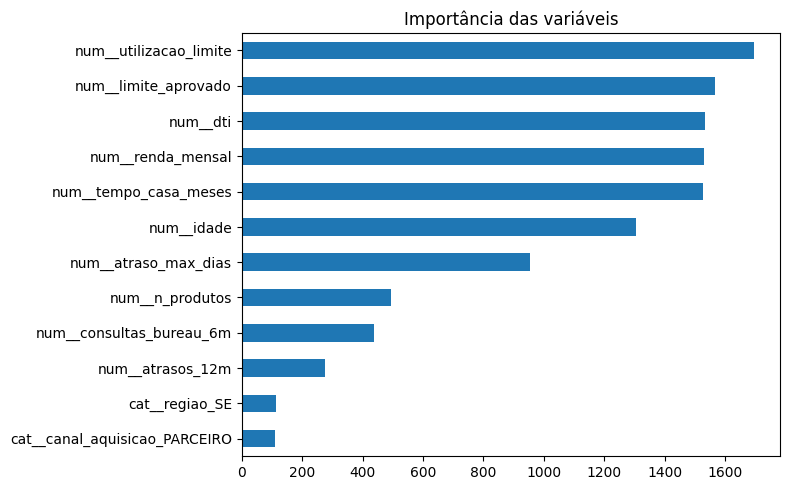

In [36]:
# [ORIGINAL — célula 13]

# Correlação entre a PD prevista e a PD verdadeira — diagnóstico que só existe em dados
# sintéticos. Mede o quanto o modelo recuperou o mecanismo real (1 = perfeito).
corr = np.corrcoef(carteira["pd"], carteira["pd_real"])[0, 1]
print(f"Correlação PD prevista x PD real: {corr:.4f}")

# Extrai o pipeline da PRIMEIRA dobra da calibração. O modelo final é a média de 3
# pipelines; olhar um só mostra 1/3 do modelo (e treinado com 2/3 dos dados).
estimador = modelo.calibrated_classifiers_[0].estimator
# Nomes das colunas depois do pré-processamento (num__..., cat__...).
nomes = estimador.named_steps["pre"].get_feature_names_out()
# Importância padrão do LightGBM = nº de vezes que a variável é usada numa divisão
# ("split"). Favorece variáveis contínuas com muitos valores distintos e diz pouco
# sobre o quanto cada variável melhora a previsão (ver P17).
imp = pd.Series(estimador.named_steps["clf"].feature_importances_, index=nomes)

# As 12 variáveis mais usadas, em barras horizontais.
top = imp.sort_values(ascending=False).head(12)
top.sort_values().plot(kind="barh", figsize=(8, 5), title="Importância das variáveis")
plt.tight_layout(); plt.show()

### 🔴 P17 — Importância por contagem de splits, de uma única dobra

- **Problema:** a importância vem de **1 dos 3** modelos da calibração e usa o critério **`split`** (quantas vezes a variável foi usada).
- **Por que é um problema:** o critério `split` favorece variáveis contínuas com muitos valores (renda, limite, idade), que oferecem muitos pontos de corte, mesmo quando elas quase não melhoram a previsão; e num modelo sobreajustado grande parte dos splits está **decorando ruído**. Variáveis redundantes (P7) dividem a importância entre si.
- **Impacto:** ranking de drivers enganoso — exatamente o que seria levado a um comitê ou usado para *reason codes* de recusa.
- **Correção:** **importância por permutação** calculada no modelo **completo** e numa amostra **fora do treino** (quanto a métrica piora quando embaralhamos a variável), e/ou **SHAP** para explicações individuais. Comparar com a verdade (aqui conhecida) mostra qual método é confiável.

In [37]:
# ✅ Correção P17 — importância por permutação do modelo COMPLETO, fora do treino.

# Permutação no OOT: embaralha cada variável 10 vezes e mede a queda do AUC. O OOT é usado
# aqui só para DIAGNÓSTICO de um modelo já fixado (nenhuma escolha é feita com isso).
perm = permutation_importance(modelo, X_oot, y_oot, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
imp_perm = pd.Series(perm.importances_mean, index=FEATURES)

# Importância por GANHO (redução de log loss) da dobra 0, somada por variável original.
ganho_dobra = pd.Series(estimador.named_steps["clf"].booster_.feature_importance("gain"), index=nomes)
raiz = lambda n: next(f for f in FEATURES if n.split("__")[1].startswith(f))
ganho_var = ganho_dobra.groupby([raiz(n) for n in ganho_dobra.index]).sum()
split_var = imp.groupby([raiz(n) for n in imp.index]).sum()

# Tabela comparativa: rankings (1 = mais importante) pelos três critérios, e o efeito
# verdadeiro (coeficiente do mecanismo × desvio-padrão da variável) como referência.
coef_verdade = {"utilizacao_limite": 3.60, "atrasos_12m": 0.42, "atraso_max_dias": 0.016, "dti": 1.90,
                "consultas_bureau_6m": 0.30, "idade": 0.030, "tempo_casa_meses": 0.016, "n_produtos": 0.14}
efeito_real = pd.Series({f: coef_verdade.get(f, np.nan) * treino[f].std() for f in FEATS_NUM})
comp_imp = pd.DataFrame({"rank split (original)": split_var.rank(ascending=False),
                         "rank ganho": ganho_var.rank(ascending=False),
                         "rank permutação (OOT)": imp_perm.rank(ascending=False),
                         "queda de AUC ao permutar": imp_perm,
                         "efeito verdadeiro (|β|·DP)": efeito_real}).sort_values("rank permutação (OOT)")
comp_imp.style.format({"queda de AUC ao permutar": "{:.4f}", "efeito verdadeiro (|β|·DP)": "{:.3f}",
                       "rank split (original)": "{:.0f}", "rank ganho": "{:.0f}", "rank permutação (OOT)": "{:.0f}"}, na_rep="—")

,rank split (original),rank ganho,rank permutação (OOT),queda de AUC ao permutar,efeito verdadeiro (|β|·DP)
utilizacao_limite,1,1,1,0.0677,0.718
tempo_casa_meses,5,2,2,0.0432,0.556
atraso_max_dias,7,7,3,0.0304,0.331
idade,6,5,4,0.0255,0.440
atrasos_12m,12,8,5,0.0180,0.377
consultas_bureau_6m,9,9,6,0.0092,0.331
n_produtos,8,10,7,0.0091,0.240
canal_aquisicao,11,12,8,0.0049,—
dti,3,3,9,0.0033,0.099
regiao,10,11,10,0.0012,—


**Leitura.** A importância por **permutação** coloca no topo as variáveis com maior efeito verdadeiro (utilização, tempo de casa, atrasos, idade, consultas), enquanto o critério **split** superestima variáveis contínuas "ricas em cortes" com efeito fraco ou nulo: `limite_aprovado` (2º por split, 11º por permutação) e `renda_mensal` (4º × 12º) chegam a ter importância por permutação **negativa** — embaralhá-las não piora (e até melhora levemente) o AUC no OOT, sinal de que o modelo as usava para decorar ruído. O `dti` também cai de 3º para 9º. A região tem permutação praticamente nula (ela de fato não tem efeito) e o canal, pequena. `renda_mensal` e `limite_aprovado` aparecem com "—" porque não têm um coeficiente linear no mecanismo (a renda entra por um degrau em R$ 9.000 e pelo DTI; o limite não entra diretamente).

Lembrete: mesmo a permutação mede **dependência do modelo**, não causalidade. Para *reason codes* de recusa (exigidos quando o cliente pede revisão de uma decisão automatizada — art. 20 da LGPD), usa-se a contribuição individual (SHAP ou pontos do scorecard), com linguagem de negócio e sem variáveis sensíveis.

## 13. Comparação final no OOT — usado uma única vez

Agora medimos, **uma única vez** e no conjunto que nenhuma escolha usou, as decisões tomadas na validação:
- **Modelos:** o modelo original do notebook, a logística (campeã na validação) e o LightGBM regularizado de 4 folhas (*challenger*), ambos re-treinados em todo o período de treino (jan–set) com as configurações escolhidas na validação.
- **Threshold:** o corte de PD de cada modelo foi escolhido **na validação**, pelo lucro realizado (seção 9), e é aplicado ao OOT sem ajuste.

In [38]:
# ✅ Comparação final — escolhas feitas na validação, medidas no OOT.

# 1) Corte de cada modelo escolhido NA VALIDAÇÃO (PD de jul–set vinda de modelos
#    treinados em jan–jun), pelo lucro realizado.
cortes_val = {"Modelo original do notebook": corte_val,
              "Regressão logística (campeã)": curva_realizada(val_dev, P_VAL["Regressão logística (baseline)"]).idxmax(),
              "LightGBM regularizado (challenger)": curva_realizada(val_dev, P_VAL["LightGBM regularizado (4 folhas)"]).idxmax()}

# 2) PDs no OOT: modelo original (já treinado) e os dois re-treinados em jan–set.
lgbm_full = lgbm_regularizado(4).fit(X_tr, y_tr)
P_OOT = {"Modelo original do notebook": pd_oot,
         "Regressão logística (campeã)": logit_full.predict_proba(X_oot)[:, 1],
         "LightGBM regularizado (challenger)": lgbm_full.predict_proba(X_oot)[:, 1]}

# 3) Painel final: discriminação com IC, calibração, economia realizada no OOT.
final = {}
for nome, p in P_OOT.items():
    m = metricas_credito(y_oot, p, cortes_val[nome])
    ic_ = auc_ic(y_oot, p)
    aprova = p <= cortes_val[nome]
    final[nome] = {"ROC-AUC": m["ROC-AUC"], "IC95% AUC": f"[{ic_[0]:.3f}, {ic_[1]:.3f}]", "KS": m["KS"],
                   "PR-AUC": m["PR-AUC"], "Brier": m["Brier"], "Log loss": m["Log loss"], "ECE": m["ECE"],
                   "PD média": m["PD média"], "Taxa real": m["Taxa real"],
                   "Corre. c/ PD verdadeira": np.corrcoef(p, oot["pd_real"])[0, 1],
                   "Corte (da validação)": cortes_val[nome], "Aprovação": aprova.mean(),
                   "Bad rate aprovados": y_oot.values[aprova].mean(),
                   "Lucro realizado (R$ mi)": lucro_real_oot[aprova].sum() / 1e6}
final = pd.DataFrame(final).T
display(final.style.format({"ROC-AUC": "{:.4f}", "KS": "{:.2f}", "PR-AUC": "{:.3f}", "Brier": "{:.5f}", "Log loss": "{:.4f}",
                            "ECE": "{:.4f}", "PD média": "{:.2%}", "Taxa real": "{:.2%}", "Corre. c/ PD verdadeira": "{:.3f}",
                            "Corte (da validação)": "{:.3f}", "Aprovação": "{:.1%}", "Bad rate aprovados": "{:.2%}",
                            "Lucro realizado (R$ mi)": "{:.3f}"}))

# 4) A diferença de AUC entre a logística e o modelo original é real? Bootstrap PAREADO:
#    as mesmas reamostragens para os dois modelos, o que elimina o ruído comum a ambos.
rng_b = np.random.default_rng(RANDOM_STATE)
yv = y_oot.values
difs = []
for _ in range(1000):
    i = rng_b.integers(0, len(yv), len(yv))
    difs.append(roc_auc_score(yv[i], P_OOT["Regressão logística (campeã)"][i]) - roc_auc_score(yv[i], pd_oot[i]))
print(f"AUC logística − AUC original: {np.mean(difs):+.4f}  IC95% [{np.percentile(difs, 2.5):+.4f}, {np.percentile(difs, 97.5):+.4f}]")

,ROC-AUC,IC95% AUC,KS,PR-AUC,Brier,Log loss,ECE,PD média,Taxa real,Corre. c/ PD verdadeira,Corte (da validação),Aprovação,Bad rate aprovados,Lucro realizado (R$ mi)
Modelo original do notebook,0.7832,"[0.758, 0.805]",44.12,0.278,0.06469,0.2339,0.0120,7.54%,7.85%,0.892,0.195,92.7%,5.84%,1.842
Regressão logística (campeã),0.8152,"[0.795, 0.836]",49.26,0.322,0.06247,0.2228,0.0078,7.50%,7.85%,0.992,0.150,86.3%,4.67%,1.944
LightGBM regularizado (challenger),0.8079,"[0.786, 0.829]",48.68,0.307,0.06327,0.2263,0.0081,7.45%,7.85%,0.964,0.135,84.8%,4.49%,1.888


AUC logística − AUC original: +0.0321  IC95% [+0.0212, +0.0430]


**Leitura.**
- A **logística** supera o modelo original em **todas** as dimensões: ordenação (AUC maior, com o IC da diferença pareada longe de zero), probabilidade (Brier e log loss menores), aderência à PD verdadeira e resultado econômico. Ela chega praticamente ao teto do oráculo (≈ 0,82).
- O **LightGBM regularizado** também supera o original com folga: o problema do original não era o algoritmo, era a **falta de regularização** e de validação.
- O modelo campeão, portanto, é o **mais simples**: com um mecanismo quase linear, a complexidade do boosting não se paga — e sem baseline o notebook original nunca teria descoberto isso.

## 14. Ordem do pipeline — original × recomendada

```
ORIGINAL                                   RECOMENDADA
Dados                                      Definição do problema (default, horizonte, data de observação)
Split treino / OOT                         Dados + dicionário (disponibilidade de cada variável)
Pré-processamento (no pipeline) ✔          Split temporal: treino | validação | OOT
Treino LightGBM + calibração               EDA  ← só no treino
Métricas no OOT                            Feature engineering (dentro do pipeline)
EL / P&L no OOT                            Baseline (logística/scorecard) + candidatos
Corte ótimo NO OOT ✘                       Tuning e escolha do modelo  ← validação
Faixas A–E (arbitrárias)                   Calibração + checagem de calibração  ← validação
PSI / stress                               Threshold e política pelo lucro REALIZADO  ← validação
CLV                                        Avaliação final, uma vez  ← OOT
Importância (1 dobra, split)               Interpretabilidade, stress test, monitoramento
EDA  ← depois de tudo ✘                    Documentação e validação independente
```

As duas inversões importantes: a **EDA** vinha no fim (não orientou a modelagem) e as **escolhas de política** eram feitas no **OOT** (contaminando a avaliação final). O pré-processamento, por outro lado, estava no lugar certo — dentro do pipeline, depois do split.

# Credit Risk — Technical Review

Auditoria do notebook original "Exemplo modelo risco de crédito 23 09". Os números citados vêm das células executadas acima.

### 1. Pontos tecnicamente corretos

| Aspecto | Evidência no código | Por que está certo |
|---|---|---|
| Split por safra (out-of-time) | Célula 3: `treino = df[df["safra"] < corte_oot]` | Imita o uso real (passado → futuro); evita o split aleatório |
| Pré-processamento dentro do pipeline | Célula 4: `Pipeline([("pre", pre), ("clf", lgbm)])` dentro de `CalibratedClassifierCV` | Mediana e encoding aprendidos só no treino de cada dobra; sem vazamento de pré-processamento |
| Lista explícita de features | Célula 3: `FEATURES = FEATS_NUM + FEATS_CAT` | `pd_real`, `ead`, `customer_id` e `safra` ficam de fora por construção |
| Robustez a categoria nova | `OneHotEncoder(handle_unknown="ignore")` | Escoragem não quebra com uma categoria nunca vista |
| Não usa `class_weight`/resampling | Célula 4 | Preserva a escala da PD (demonstrado: `balanced` levaria a PD média a 37% numa carteira de ~8%) |
| Calibração da PD | `CalibratedClassifierCV(..., method="isotonic", cv=3)` | A PD vai para EL e preço; a calibração ficou aceitável no OOT (PD média 7,5% × 7,9% observada; nenhum teste binomial por faixa rejeitado) |
| Métricas de mercado | AUC, Gini, KS, Brier | Adequadas para ordenação e qualidade probabilística (mas incompletas — item 5) |
| Threshold econômico, não 0,5 | Células 8–9: curva de lucro por corte | Decisão de crédito derivada da economia (margem, LGD, custo), com contraste explícito ao 0,5 |
| EL = PD × LGD × EAD e lucro ajustado ao risco | Célula 6 | Liga o modelo ao P&L; receita ponderada por (1 − PD) |
| Monitoramento e stress | Célula 11: PSI sob choque macro | Preocupação com estabilidade é rara em notebooks de portfólio |
| Reprodutibilidade | Seeds fixas; `default_rng(seed)` | O notebook reexecuta com resultados idênticos |

### 2. Problemas encontrados

| # | Problema | Gravidade | Seção |
|---|---|---|---|
| P1 | Evento de default, horizonte e data de observação não definidos | Alta (governança) | 1 |
| P2 | Missing simulado como aleatório; DTI calculado com a renda "apagada" | Média | 2, 4 |
| P3 | `limite_aprovado` (decisão do banco) usado como feature — circularidade | Média | 2 |
| P4 | EAD = saldo atual, sem CCF (e sem efeito da própria decisão de limite) | Média | 2 |
| P5 | OOT sem dinâmica temporal; **sem conjunto de validação** — escolhas feitas no teste | **Alta** | 3 |
| P6 | EDA depois do modelo e sobre a base inteira (inclui o OOT) | Média | 4 |
| P7 | Multicolinearidade não analisada (Spearman 0,93; VIF até ~8) | Média | 4 |
| P8 | `subsample=0.9` inativo (falta `subsample_freq`) — **bug de configuração** | Média | 5 |
| P9 | Sem baseline, sem tuning, sem diagnóstico de overfitting (AUC treino 0,99 × OOT 0,78) | **Alta** | 5 |
| P10 | Métricas sem IC, sem referência, sem PR-AUC/log loss | Média | 6 |
| P11 | Calibração feita, mas nunca verificada | Média | 6 |
| P12 | LGD, margem e custo assumidos; sem custo de capital | Média | 8 |
| P13 | Corte escolhido no OOT e avaliado com o lucro **previsto** pelo próprio modelo | **Alta** | 9 |
| P14 | Faixas A–E arbitrárias e inconsistentes com o corte ótimo | Média | 9 |
| P15 | Stress test sem rótulos sob choque; "RECALIBRAR" deduzido só do PSI | Média | 10 |
| P16 | CLV com premissas ad hoc (fator 0,7; PD constante; perda não descontada) | Baixa | 11 |
| P17 | Importância por nº de splits, de 1 das 3 dobras | Média | 12 |

#### Checklist metodológico (itens pedidos na revisão)

| Item verificado | Veredito | Evidência |
|---|---|---|
| Data leakage | 🟢 Não encontrado no modelo | Features explícitas; `pd_real` excluída; pré-processamento no pipeline |
| Target leakage | 🟢 Não encontrado (🟡 não demonstrável) | Nenhuma variável posterior ao evento; falta data de observação (P1) |
| Train/test contamination | 🟢 Não no ajuste do modelo | OOT fora do `fit` e da calibração; 1 linha por cliente |
| Uso incorreto do conjunto de teste | 🔴 Sim | Corte ótimo e ganho da política escolhidos e medidos no OOT (P13); EDA sobre o OOT (P6) |
| Preprocessing antes do split | 🟢 Não ocorre | `SimpleImputer`/`OneHotEncoder` dentro do `Pipeline` |
| Validação inadequada | 🔴 Sim | Sem conjunto de validação; sem baseline; sem diagnóstico treino × teste (P5, P9) |
| Random split quando deveria ser temporal | 🟢 Split por safra (🟡 safras sorteadas no gerador) | P5 |
| Tratamento inadequado de dados faltantes | 🟡 Parcial | Mediana sem flag de missing; missing MCAR irrealista; DTI inconsistente (P2) |
| Tratamento inadequado de outliers | 🟡 Não analisado | Truncamentos do gerador criam massas nos limites; o boosting é robusto, a logística exigiria log/winsorização (seção 4) |
| Variáveis altamente correlacionadas | 🔴 Sim, não analisadas | `atrasos_12m` × `atraso_max_dias` (Spearman 0,93); renda × limite e utilização × DTI (0,81) (P7) |
| Multicolinearidade | 🔴 Sim, não analisada | VIF até 7,7; sinal da renda contraintuitivo na logística (P7) |
| Overfitting | 🔴 Severo | AUC treino 0,994 × OOT 0,781 (P9) |
| Underfitting | 🟢 Não | A logística tem gap pequeno e AUC perto do oráculo |
| Class imbalance | 🟢 Tratado corretamente | Sem `class_weight`/resampling; threshold econômico |
| Métricas inadequadas | 🟡 Incompletas | Sem IC, PR-AUC, log loss, calibração (P10, P11) |
| Threshold arbitrário | 🟢 Econômico (🔴 escolhido no teste); 🟡 faixas A–E arbitrárias | P13, P14 |
| Problemas de calibração | 🟡 Calibração feita e boa, mas não verificada; falha sob estresse | P11, P15 |
| Ausência de validação temporal | 🔴 Sim (só treino × OOT) | P5 |
| Features indisponíveis na decisão | 🟢 Nenhuma encontrada; 🟡 `limite_aprovado` é decisão do banco | P3 |

Menores: importações não usadas (`train_test_split`, `roc_curve`); KS não trata empates (diferença de 0,02 ponto aqui); reimportações de `matplotlib`/`seaborn` no meio do notebook; `apply` linha a linha onde `pd.cut` seria vetorizado.

### 3. Data Leakage

- **Target leakage (variável do futuro):** **não encontrado**. Nenhuma feature é medida depois do evento, e `pd_real` está corretamente excluída. Ressalva: sem data de observação documentada (P1), a ausência de leakage não pode ser **provada** — só inferida da construção sintética.
- **Leakage de pré-processamento:** **não há**. Imputação e encoding estão dentro do pipeline, depois do split.
- **Contaminação treino/teste:** **não há** no ajuste do modelo (o OOT não participa do `fit`, nem da calibração). Cada cliente aparece uma vez, então não há o mesmo cliente dos dois lados.
- **Uso indevido do conjunto de teste:** **sim** — (a) o corte ótimo de PD e o "ganho da política" são escolhidos e medidos no OOT (P13); (b) a EDA olha o OOT (P6). É contaminação da **avaliação**, não do modelo: os números de política reportados não são estimativas honestas (escolha no teste + lucro previsto em vez de realizado).
- **Informação que o banco não teria:** o `dti` dos clientes sem renda é calculado com a renda verdadeira (P2) — um vazamento de informação do gerador, sem efeito prático aqui porque o missing é aleatório.
- **Circularidade:** `limite_aprovado` embute a política antiga (P3).

### 4. Model Validation

- **Estratégia original:** treino (jan–set) × OOT (out–dez). O desenho temporal é o correto, mas: (a) como as safras são sorteadas, o OOT é na prática um holdout aleatório (qui-quadrado entre safras: p = 0,63) e não testa estabilidade temporal; (b) sem validação, todas as escolhas posteriores usam o OOT.
- **Overfitting:** severo — AUC de treino 0,994 × OOT 0,781 (gap 0,21). O modelo decorou o treino.
- **Underfitting:** não se aplica ao original; a logística também não sofre underfitting porque o mecanismo é linear no log-odds.
- **Recomendação implementada:** treino (jan–jun) | validação (jul–set) | OOT (out–dez); escolhas na validação; OOT usado uma única vez. Com essa disciplina, a logística e o LightGBM regularizado superam o original no OOT (AUC 0,815 e 0,808 × 0,783; diferença logística − original = +0,032, IC 95% [+0,021; +0,043]).
- **O que falta para um padrão profissional:** backtesting por safra (quando os dados tiverem tempo real), CV temporal (*expanding window*) para estabilidade dos hiperparâmetros, testes de estabilidade dos coeficientes/importâncias entre períodos e validação independente (2ª linha).

### 5. Metrics

- **Adequadas:** AUC/Gini e KS para ordenação; Brier para qualidade probabilística. Accuracy e F1 **não** foram usadas como critério — correto.
- **Insuficientes:** sem IC (o AUC do OOT tem IC de ±0,02, [0,758; 0,805]); sem referência (Brier Skill Score 0,11; oráculo com AUC 0,818); sem PR-AUC (0,28, ou 3,5× a prevalência); sem log loss.
- **A régua do KS** ("bom" para 44) é heurística e depende da população; deveria vir com IC e comparação com o baseline (a logística tem KS 49,3).
- **Métricas de decisão** (aprovação, bad rate dos aprovados, lucro) são as que importam para o negócio — e precisam ser **realizadas** (com o default observado), não esperadas (P13).

### 6. Calibration

- **Existe calibração** (isotônica com CV), mas **não existe análise de calibração** no original (P11).
- **Resultado da verificação:** no OOT, PD média 7,54% × taxa observada 7,85% (calibration-in-the-large aceitável); por faixa de PD, nenhum teste binomial rejeitado (p-valores de 0,18 a 0,91); ECE 0,012 (a logística tem 0,008). O LightGBM **sem** calibração subestimaria fortemente a PD (média de 6,5% no OOT), então a calibração foi necessária **para este modelo sobreajustado**.
- **Não é suficiente para produção:** falta (a) curva de calibração no relatório, (b) backtesting por rating ao longo das safras, (c) política de recalibração (gatilhos, janela), (d) ajuste **PIT/TTC** conforme o uso (provisão × capital), e (e) PD *lifetime* se o uso for IFRS 9 / CMN 4.966 (estágios 2 e 3).
- **Lição do stress test:** sob choque, o modelo calibrado passa a **subestimar** o risco (PD prevista 16,2% × verdadeira 22,5% no choque de 1,5), porque árvores não extrapolam. Calibração é uma propriedade **do modelo numa população**, e não uma garantia permanente.

### 7. Production Risk

1. **Overfitting ⇒ instabilidade:** um modelo com AUC de treino 0,99 tende a oscilar entre safras e a reagir mal a mudanças pequenas de população.
2. **Extrapolação sob estresse:** em cenários adversos, o boosting subestima a PD (seção 10) — exatamente quando a provisão mais importa.
3. **Circularidade de política:** `limite_aprovado` muda de significado se a política de limites mudar (P3); a decisão de "limite ampliado" aumenta a EAD que o P&L não considera (P4, P14).
4. **Missing informativo em produção:** se a renda passar a faltar de forma não aleatória (autônomos, canais digitais), a imputação pela mediana sem flag subestima o risco (P2).
5. **Drift e *concept drift*:** PSI detecta mudança de população, mas não mudança de relação; sem backtesting por safra, um modelo errado pode passar meses "verde".
6. ***Training–serving skew*:** o DTI em produção precisa ser calculado exatamente como no treino (inclusive quando falta renda); variáveis de janela (12m, 6m) precisam do mesmo corte de data.
7. **Governança e regulação:** sem definição de default e horizonte (P1), sem documentação de premissas (LGD, margem) e sem *reason codes*, o modelo não passa por validação independente nem atende a pedidos de revisão de decisão automatizada (art. 20 da LGPD).
8. **Equidade:** `idade` e `regiao` são variáveis sensíveis do ponto de vista reputacional e regulatório; a região não tem sinal estatístico (p = 0,56) e deveria sair; o uso da idade precisa de justificativa de negócio e de monitoramento de calibração por faixa etária.

### 8. Melhorias recomendadas (em ordem de impacto)

1. **Criar validação temporal** e mover para ela todas as escolhas (modelo, hiperparâmetros, corte, faixas); usar o OOT uma única vez. *(implementado nesta revisão)*
2. **Adotar a logística como campeã** (ou um scorecard WoE) e o LightGBM regularizado como *challenger*: melhor AUC, Brier, log loss, aderência à PD verdadeira e lucro realizado no OOT. *(implementado)*
3. **Corrigir o LightGBM:** `subsample_freq=1`, menos folhas, `min_child_samples` maior, `reg_lambda`, *early stopping* na validação. *(implementado)*
4. **Avaliar a política pelo lucro realizado** e considerar a regra de **equilíbrio individual** (lucro esperado > 0), que gerou R$ 1,905 mi realizados × R$ 1,862 mi do corte único. *(implementado)*
5. **Documentar o problema:** evento de default, horizonte, data de observação, população, exclusões. *(proposto)*
6. **Tratar missing e redundância:** `add_indicator=True`, DTI ausente quando a renda falta, remover `atraso_max_dias` ou `atrasos_12m`, retirar `regiao`, reavaliar `limite_aprovado`. *(parcialmente implementado na logística)*
7. **Completar a avaliação:** IC por bootstrap, PR-AUC, log loss, ECE, curva de calibração e testes binomiais por faixa. *(implementado)*
8. **Stress test consistente**, com a PD verdadeira ou cenários de especialistas, e monitoramento baseado em backtesting — não só em PSI. *(implementado para os dados sintéticos)*
9. **Estimar LGD e CCF**, incluir custo de capital e fazer análise de sensibilidade do corte às premissas. *(proposto)*
10. **Interpretabilidade para produção:** permutação/SHAP no modelo completo, *reason codes* e checagem de equidade. *(permutação implementada)*

### 9. Nível do projeto

| Dimensão | Nível | Justificativa |
|---|---|---|
| **Escopo / visão de negócio** | **Avançado** | Cobre PD, EL, lucro ajustado ao risco, curva de política, faixas de decisão, PSI, stress e CLV — a cadeia completa de valor de um modelo de crédito, algo raro em notebooks de estudo. |
| **Desenho dos dados** | Intermediário | Mecanismo causal conhecido e `pd_real` para diagnóstico são ótimas escolhas didáticas; mas safras sem dinâmica, missing MCAR, DTI inconsistente e EAD sem CCF tornam a base "fácil demais" para testar o que o notebook quer testar. |
| **Validação** | Básico-intermediário | Split temporal correto na forma, mas sem validação, com escolhas no teste, sem baseline e sem diagnóstico de overfitting — as falhas que mais pesam numa validação independente. |
| **Modelagem** | Intermediário | Pipeline bem montado e calibração correta; mas um único modelo, sem tuning, com um hiperparâmetro inativo e overfitting severo, perdendo para uma logística simples por 0,03 de AUC. |
| **Avaliação e calibração** | Intermediário | Métricas certas, mas sem incerteza, sem referência e sem verificação de calibração. |
| **Economia e política** | Intermediário-avançado | O raciocínio (break-even, EL, curva de lucro) é de nível profissional; a execução (lucro previsto em vez de realizado, corte no teste, faixas arbitrárias) não é. |
| **Monitoramento e interpretabilidade** | Intermediário | Boa intenção (PSI, stress, importância); leituras que confundem mudança de população com erro do modelo e importância enviesada. |
| **Governança e documentação** | Básico | Sem definição de default, sem premissas documentadas, sem análise de risco de modelo. |

**Veredito:** o notebook mostra **maturidade de negócio de nível sênior** — pensa em PD como insumo de perda, lucro e política, e não em "acurácia" — e **rigor metodológico de nível intermediário**. Os três achados que impediriam a aprovação por uma área de validação são: **(1) escolhas feitas no conjunto de teste**, **(2) ausência de baseline, que esconde que o modelo escolhido é pior que uma logística**, e **(3) overfitting severo não diagnosticado**. Todos são corrigíveis sem mudar a arquitetura do projeto, e as correções desta revisão mostram o ganho: **+0,032 de AUC** no OOT e **+R$ 0,10 mi** de lucro realizado no semestre com o modelo campeão, sobre a mesma base e as mesmas premissas econômicas.

**O modelo original poderia ir para produção?** **Não** no estado atual: além dos problemas de validação, falta a documentação mínima (definição de default, premissas de LGD/EAD, escopo de uso). Com as correções desta revisão, a **logística** seria uma candidata razoável a campeã num ambiente de teste controlado (*shadow mode*), sujeita a validação independente e ao monitoramento por backtesting.